In [3]:
knitr::opts_chunk$set(
  echo = TRUE,
  comment = "#>",
  fig.width = 9,
  fig.height = 6,
  fig.align = "center",
  warning = FALSE,
  message = FALSE
)

# Contexto y Objetivos del Análisis

Este documento desarrolla la exploración multidimensional del conjunto de datos `bronze/synthetic_credit_card_customer_behavior_dataset.csv`. Integra de manera secuencial y exhaustiva los métodos, herramientas conceptuales y requerimientos desarrollados a lo largo de las **Semanas 1 a 3**:

* **Semana 1 (S01):** La matriz de datos $\mathbf{X}$, dimensiones ($n \times p$), clasificación de variables, medidas univariadas y bivariadas, y matrices de correlación y dispersión (`pairs`).
* **Semana 2 (S02):** Flujo de importación reproducible (`readLines`), auditoría de integridad, diagnóstico multivariante de datos faltantes (`complete.cases` vs `is.na`), verificación de duplicados e inconsistencias numéricas.
* **Semana 3 (S03):** Visualización en el espacio, impacto del número de clases en histogramas (`breaks` y regla de Sturges), análisis de dispersión y atípicos univariados con boxplots y la regla de Tukey ($1.5 \cdot RIC$), boxplots multivariados estandarizados (`scale`), y la demostración formal y gráfica del **"punto imposible"** (outlier multivariante no detectable univariadamente).

---

# Módulo 1: Inspección Previa e Importación Reproducible (S02)

## Mirar antes de leer (`readLines`)

Antes de cargar cualquier archivo en memoria, es una buena práctica de reproducibilidad inspeccionar sus primeras líneas en crudo para verificar delimitadores de columnas, separadores decimales y presencia de encabezados.

In [4]:
ruta_credit <- "../data/bronze/synthetic_credit_card_customer_behavior_dataset.csv"
lineas_muestra <- readLines(ruta_credit, n = 4)
lineas_muestra

[1] "Customer_ID,Age,Gender,Annual_Income,Occupation,Card_Type,Credit_Limit,Card_Age_Months,Monthly_Spending,Monthly_Transactions,Avg_Transaction_Value,Online_Shopping_Spending,Grocery_Spending,Fuel_Spending,Dining_Spending,Travel_Spending,Entertainment_Spending,Utility_Bill_Spending,Outstanding_Balance,Statement_Balance,Payment_Amount,Payment_Ratio,Credit_Utilization,Cash_Advance_Amount,EMI_Count,International_Transactions,Reward_Points_Earned,Reward_Points_Redeemed,Mobile_App_Login,Credit_Score"
[2] "CC100000,33,M,787406,Self-Employed,Silver,220000.0,20,36733.49,83,427.21,1317.13,9400.14,4339.48,10476.83,3092.29,2275.83,5831.79,149956.45,178851.64,82271.75,0.46,0.7,14839.84,2,0,1081,210,23,492"                                                                                                                                                                                                                                                                                                            
[3] "CC100001,58,M,598084,Retired,Basic,112000.0,101,30212.78,72,399.89,3892.84,6134.61,3442.74,3869.99,2020.56,2639.89,8212.15,84159.21,110031.93,104530.33,0.95,0.76,0.0,2,0,606,163,22,607"                                                                                                                                                                                                                                                                                                                        
[4] "CC100002,40,F,1710737,Private Employee,Platinum,928000.0,12,115895.71,142,837.85,13547.09,40293.0,11946.73,6272.35,1440.7,8502.96,33892.88,342440.99,424486.51,148570.28,0.35,0.38,73713.82,2,3,6857,0,48,549"

**Diagnóstico preliminar:**
* **Separador de columnas:** Coma (`,`).
* **Separador decimal:** Punto (`.`).
* **Encabezado:** Presente en la primera fila con nombres descriptivos de variables.
* **Estrategia de lectura:** Corresponde utilizar `read.csv()` con `header = TRUE`, `sep = ","`, `dec = "."` y `stringsAsFactors = FALSE`.

## Importación explícita

In [5]:
credit <- read.csv(
  file = ruta_credit,
  header = TRUE,
  sep = ",",
  dec = ".",
  stringsAsFactors = FALSE
)

## Dimensiones de la matriz de datos ($\mathbf{X} \in \mathbb{R}^{n \times p}$)

In [6]:
dim_matriz <- dim(credit)
dim_matriz

[1] 50000    30

La matriz de datos contiene:
* $n = `r nrow(credit)`$ observaciones (clientes simulados / filas).
* $p = `r ncol(credit)`$ variables medidas (columnas).

## Estructura y clasificación de variables (S01 & Everitt & Hothorn)

In [7]:
str(credit)

'data.frame':	50000 obs. of  30 variables:
 $ Customer_ID               : chr  "CC100000" "CC100001" "CC100002" "CC100003" ...
 $ Age                       : int  33 58 40 42 19 19 18 51 35 38 ...
 $ Gender                    : chr  "M" "M" "F" "M" ...
 $ Annual_Income             : int  787406 598084 1710737 712664 1504662 1554404 1127008 546395 577570 774834 ...
 $ Occupation                : chr  "Self-Employed" "Retired" "Private Employee" "Private Employee" ...
 $ Card_Type                 : chr  "Silver" "Basic" "Platinum" "Silver" ...
 $ Credit_Limit              : num  220000 112000 928000 211000 572000 563000 439000 91000 94000 140000 ...
 $ Card_Age_Months           : int  20 101 12 54 44 59 38 44 74 81 ...
 $ Monthly_Spending          : num  36733 30213 115896 21804 91039 ...
 $ Monthly_Transactions      : int  83 72 142 64 67 66 49 66 46 70 ...
 $ Avg_Transaction_Value     : num  427 400 838 357 1367 ...
 $ Online_Shopping_Spending  : num  1317 3893 13547 7583 19794 ...
 $ 

En la taxonomía del análisis multivariante (Everitt & Hothorn, Cap. 1), las $p = `r ncol(credit)`$ variables se clasifican en:

1. **Variables Cuantitativas / Numéricas (`r sum(sapply(credit, is.numeric))`):**
   * *Continuas de escala monetaria y gastos:* `Annual_Income`, `Monthly_Spending`, `Avg_Transaction_Value`, `Online_Shopping_Spending`, `Grocery_Spending`, `Fuel_Spending`, `Dining_Spending`, `Travel_Spending`, `Entertainment_Spending`, `Utility_Bill_Spending`, `Cash_Advance_Amount`, `Outstanding_Balance`, `Statement_Balance`, `Payment_Amount`, `Credit_Limit`.
   * *Continuas / Ratios e Índices:* `Payment_Ratio`, `Credit_Utilization`.
   * *Discretas / Conteos y Puntuaciones:* `Age`, `Card_Age_Months`, `Monthly_Transactions`, `EMI_Count`, `International_Transactions`, `Reward_Points_Earned`, `Reward_Points_Redeemed`, `Mobile_App_Login`, `Credit_Score`.
2. **Variables Cualitativas / Categóricas (`r sum(sapply(credit, is.character))`):**
   * *Nominales:* `Customer_ID` (identificador único), `Gender`, `Occupation`, `Card_Type`.

---

# Módulo 2: Auditoría y Diagnóstico de Calidad de la Matriz (S02)

## Diagnóstico multivariante de datos faltantes

Un concepto central de la estadística multivariante es que un dato faltante no es solo una celda vacía: al descartar una fila incompleta en un análisis conjunto, se pierde el vector completo $\mathbf{x}_i \in \mathbb{R}^p$.

In [8]:
total_celdas <- prod(dim(credit))
celdas_na <- sum(is.na(credit))
pct_celdas_na <- (celdas_na / total_celdas) * 100

filas_completas <- sum(complete.cases(credit))
pct_filas_completas <- (filas_completas / nrow(credit)) * 100

# Conteo por columna
faltantes_por_col <- colSums(is.na(credit))
faltantes_por_col[faltantes_por_col > 0]

named numeric(0)

* **Total de celdas en la matriz:** `r format(total_celdas, big.mark = ",")`
* **Celdas vacías (`NA`):** `r celdas_na` (`r sprintf("%.2f%%", pct_celdas_na)`)
* **Filas completas (`complete.cases`):** `r format(filas_completas, big.mark = ",")` (`r sprintf("%.2f%%", pct_filas_completas)`)

> **Conclusión:** La matriz $\mathbf{X}$ está $100\%$ completa. No se presentan discrepancias entre estrategias de casos completos (`use = "complete.obs"`) y completitud por pares (`use = "pairwise.complete.obs"`).

## Verificación de duplicados e identificadores

In [9]:
n_duplicados_filas <- sum(duplicated(credit))
n_duplicados_id <- sum(duplicated(credit$Customer_ID))

* **Filas exactamente duplicadas:** `r n_duplicados_filas`
* **Identificadores de cliente repetidos:** `r n_duplicados_id`

## Resumen univariado global y revisión de rangos (`summary`)

In [10]:
summary(credit)

    Customer_ID         Age              Gender      Annual_Income    
 Length   :50000   Min.   :18.00   Length   :50000   Min.   : 100050  
 N.unique :50000   1st Qu.:27.00   N.unique :    2   1st Qu.: 657774  
 N.blank  :    0   Median :34.00   N.blank  :    0   Median :1127630  
 Min.nchar:    8   Mean   :36.08   Min.nchar:    1   Mean   :1479318  
 Max.nchar:    8   3rd Qu.:44.00   Max.nchar:    1   3rd Qu.:1663624  
                   Max.   :70.00                     Max.   :7995831  
     Occupation        Card_Type      Credit_Limit     Card_Age_Months 
 Length   :50000   Length   :50000   Min.   :  16000   Min.   :  1.00  
 N.unique :    6   N.unique :    5   1st Qu.: 157000   1st Qu.: 31.00  
 N.blank  :    0   N.blank  :    0   Median : 396000   Median : 48.00  
 Min.nchar:    7   Min.nchar:    4   Mean   : 709677   Mean   : 53.63  
 Max.nchar:   19   Max.nchar:    9   3rd Qu.: 779000   3rd Qu.: 70.00  
                                     Max.   :6591000   Max.   :240.00  

No se detectan valores centinela de error (como `-99`, `999` o ingresos negativos). Los límites de edad ($18$ a $69$ años), ratios de pago ($0.1$ a $1.0$) y utilización crediticia ($0.03$ a $0.98$) son coherentes con las reglas de negocio.

## Tablas de frecuencia para variables categóricas

In [11]:
table(credit$Gender, useNA = "always")
table(credit$Card_Type, useNA = "always")
table(credit$Occupation, useNA = "always")


    F     M  <NA> 
22392 27608     0 


    Basic      Gold  Platinum Signature    Silver      <NA> 
    10261     16895      8284      2504     12056         0 


     Business Owner Government Employee    Private Employee             Retired 
               6038                7595               20960                4047 
      Self-Employed             Student                <NA> 
               7440                3920                   0 

---

# Módulo 3: Análisis Univariado y la Decisión Gráfica del Histograma (S01 & S03)

## Estadísticos descriptivos univariados

In [28]:
# Selección de la variable Credit_Score para estudio univariado
score <- credit$Credit_Score

media_cs <- mean(score)
sd_cs <- sd(score)
mediana_cs <- median(score)
min_cs <- min(score)
max_cs <- max(score)

c(Media = media_cs, Desv_Std = sd_cs, Mediana = mediana_cs, Min = min_cs, Max = max_cs)

Media  Desv_Std   Mediana       Min       Max 
628.98458  68.44425 638.00000 367.00000 792.00000

In [34]:
ceiling(log2(nrow(credit))) + 1

[1] 17

## El histograma y el efecto del número de cortes (`breaks`) (S03 - Sesión 4)

El histograma es una estimación no paramétrica de la función de densidad subyacente. La elección de la cantidad de intervalos (`breaks` o ancho de clase $h$) altera profundamente la percepción de la distribución:

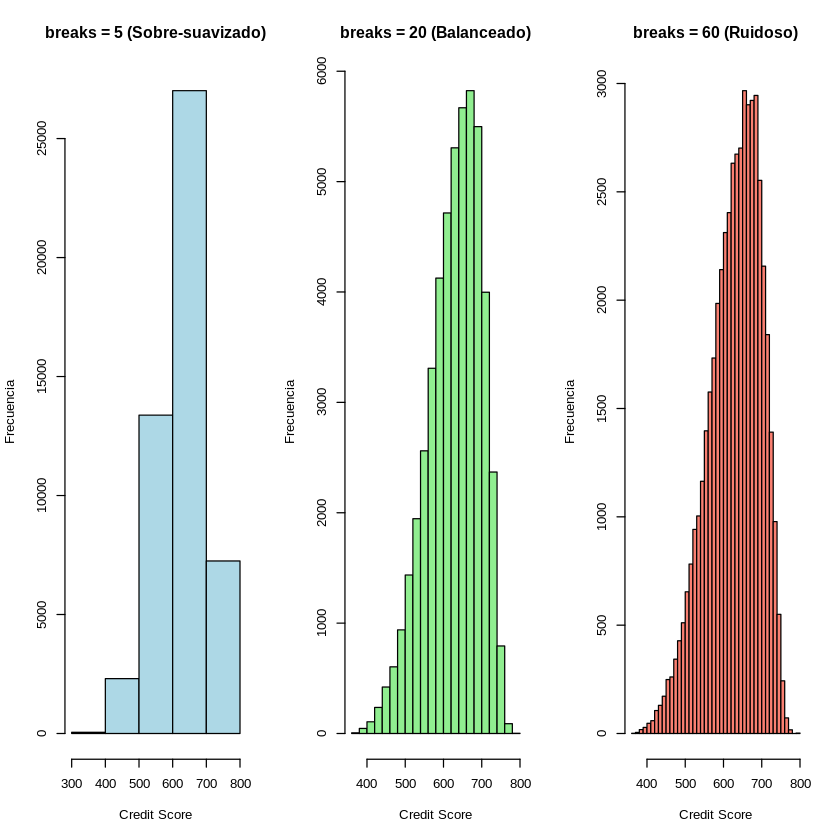

In [13]:
par(mfrow = c(1, 3))

# Histograma con muy pocos cortes (sobre-suavizado / underfitting)
hist(score, breaks = 5, col = "lightblue", border = "black",
     main = "breaks = 5 (Sobre-suavizado)",
     xlab = "Credit Score", ylab = "Frecuencia")

# Histograma con cortes intermedios
hist(score, breaks = 20, col = "lightgreen", border = "black",
     main = "breaks = 20 (Balanceado)",
     xlab = "Credit Score", ylab = "Frecuencia")

# Histograma con demasiados cortes (ruidoso / overfitting)
hist(score, breaks = 60, col = "salmon", border = "black",
     main = "breaks = 60 (Ruidoso)",
     xlab = "Credit Score", ylab = "Frecuencia")

par(mfrow = c(1, 1))

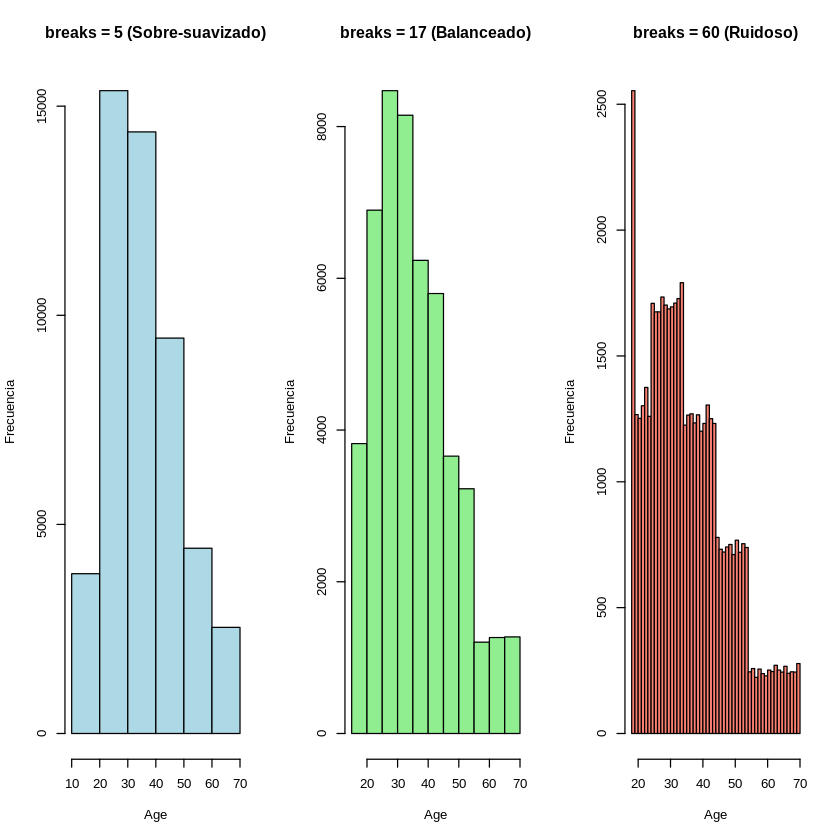

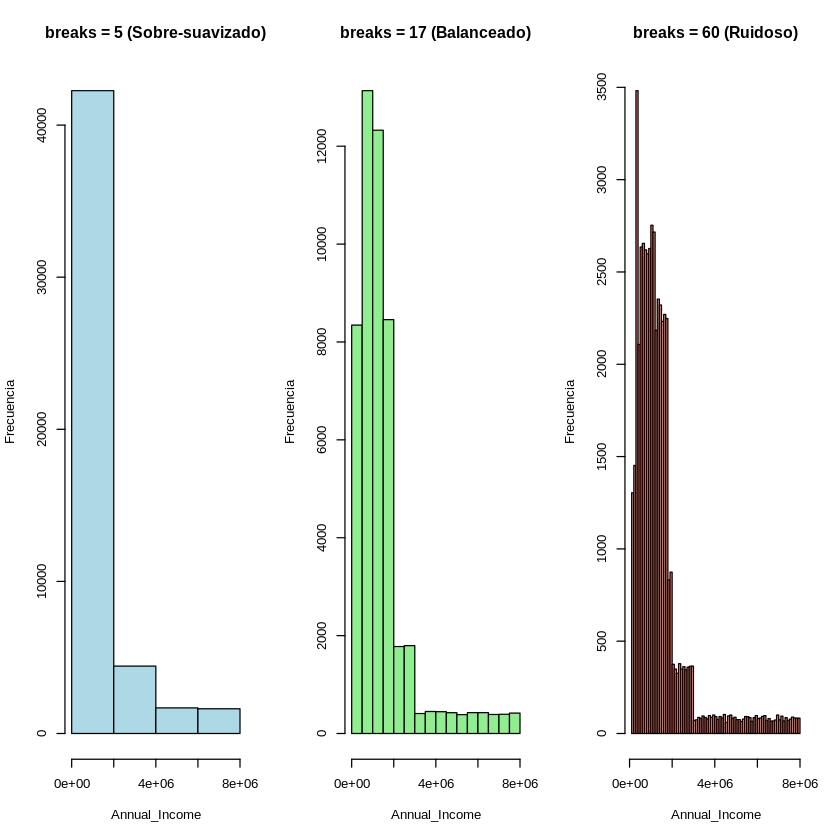

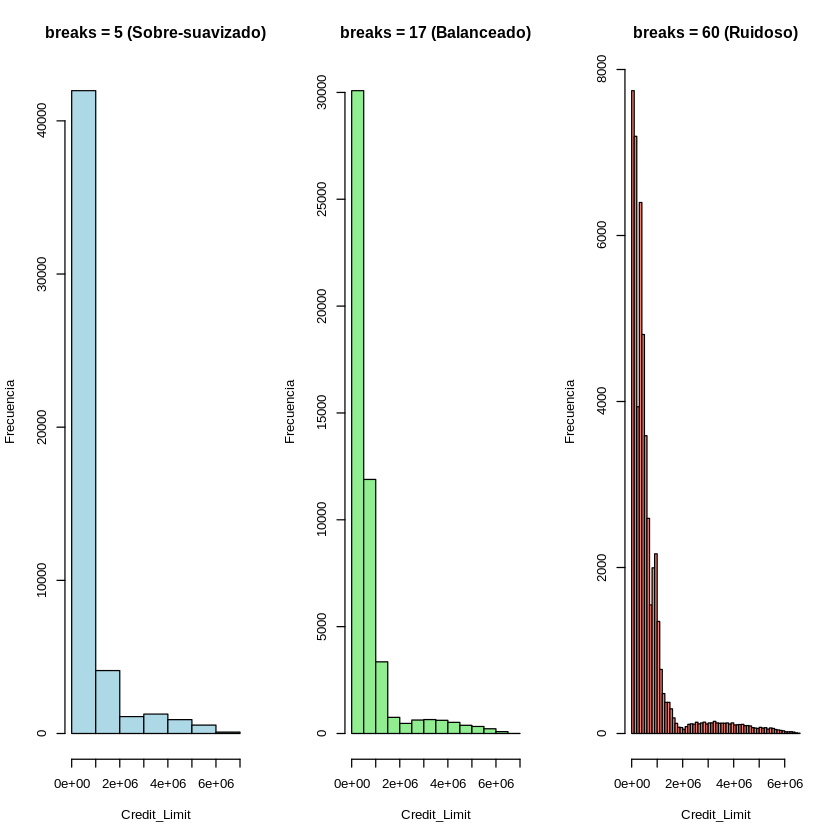

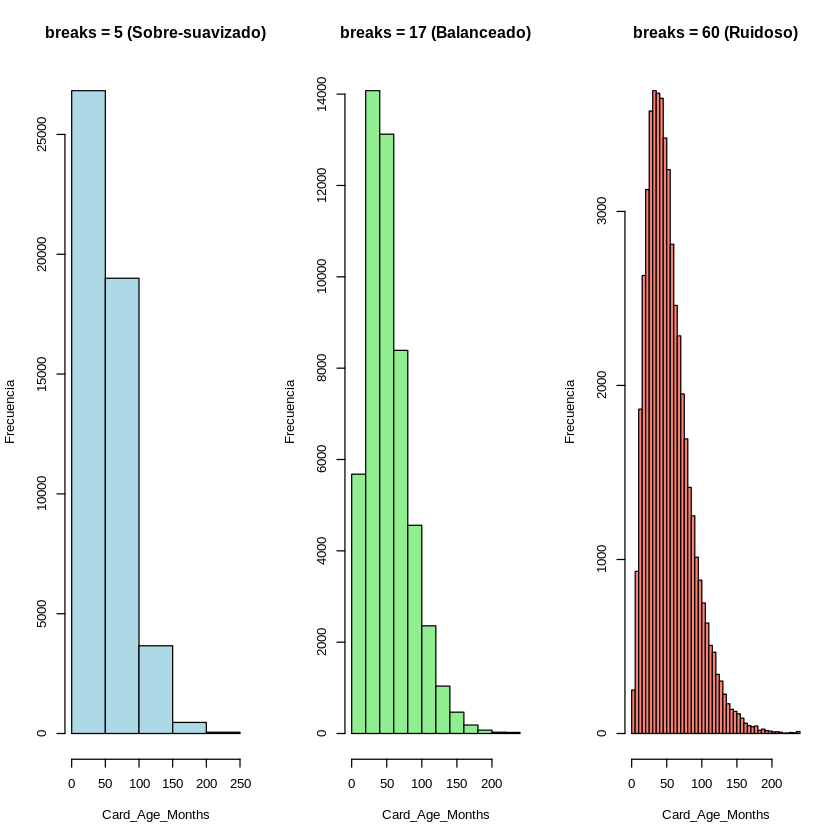

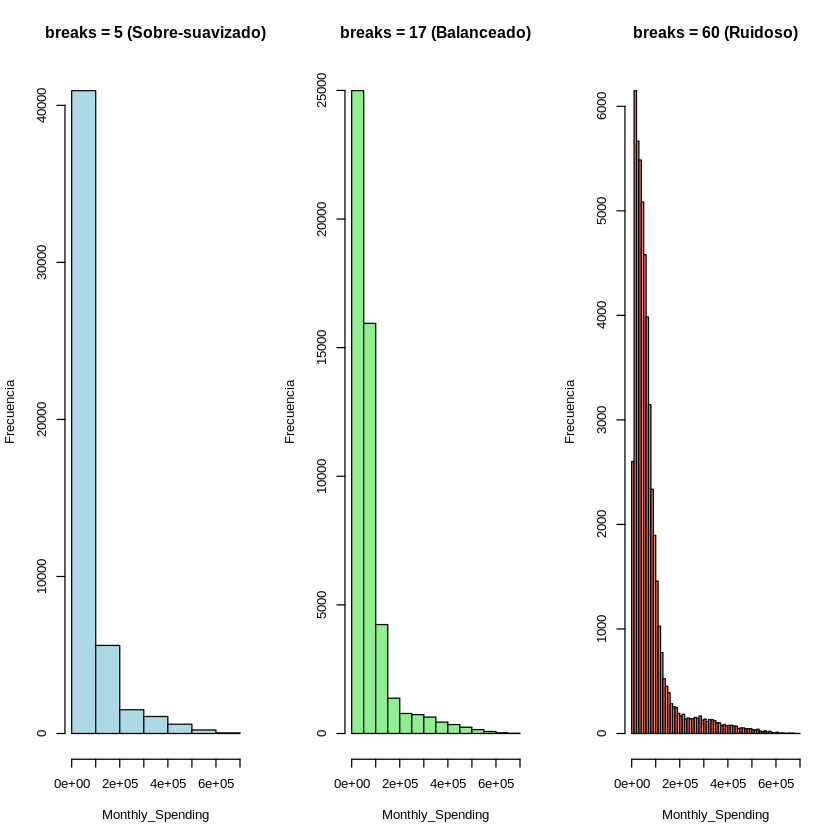

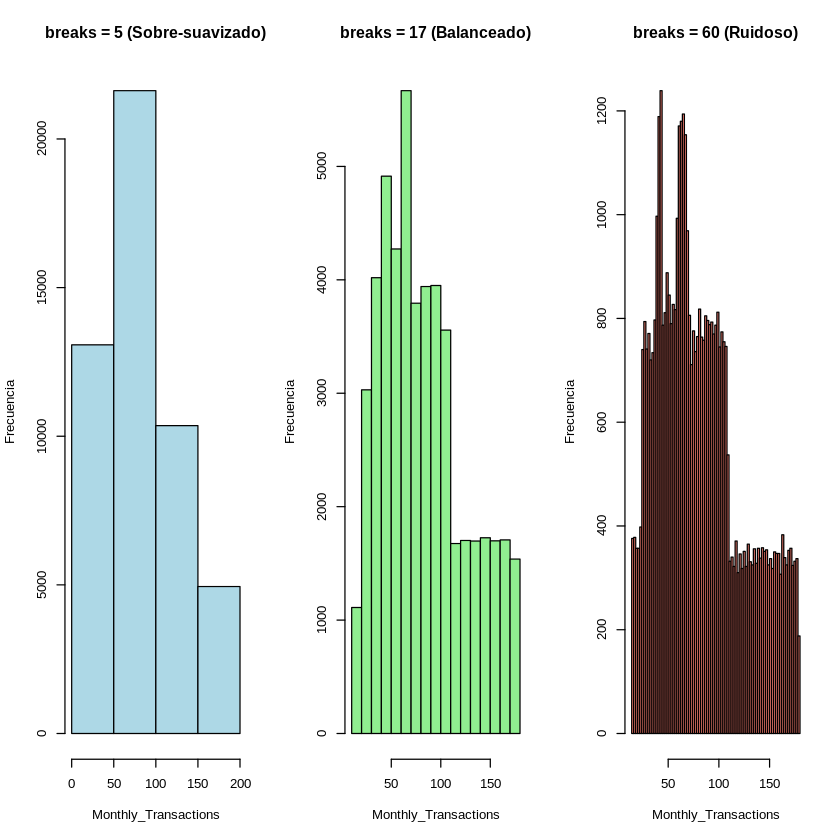

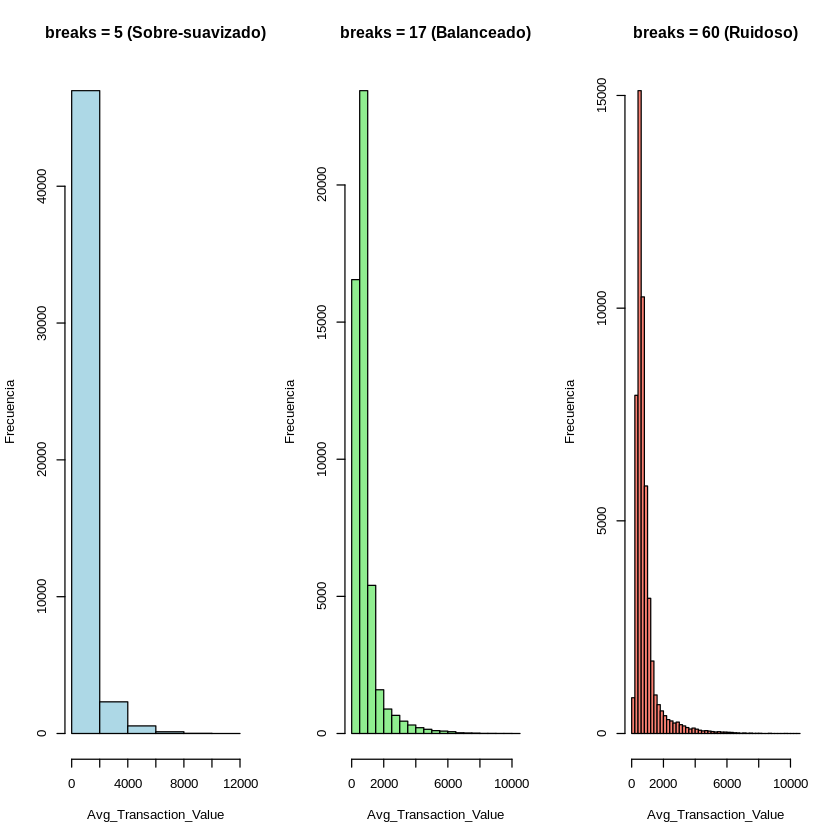

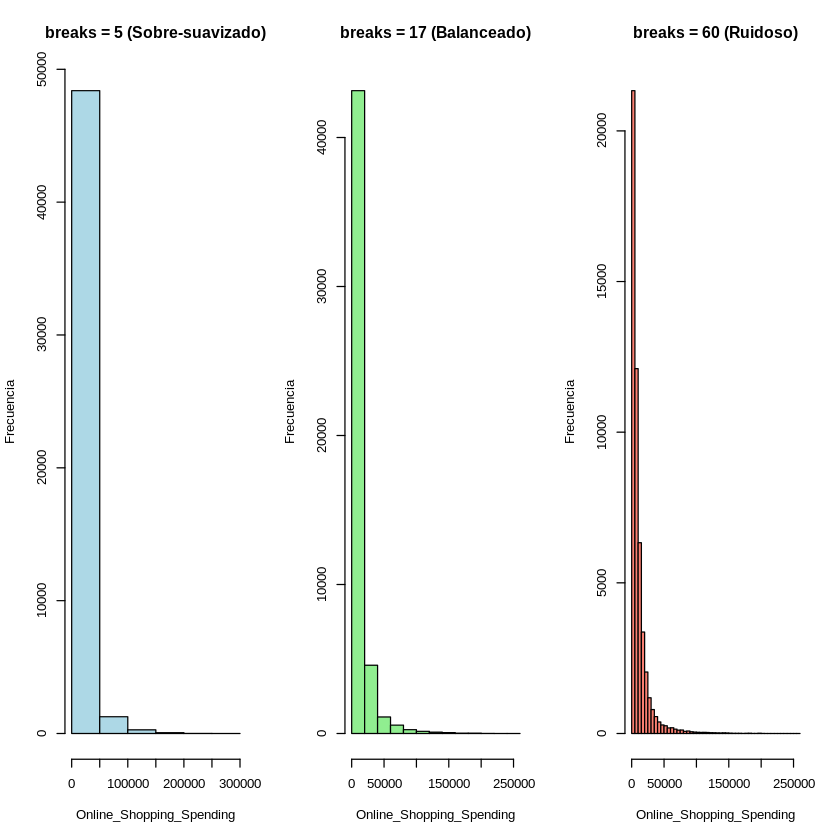

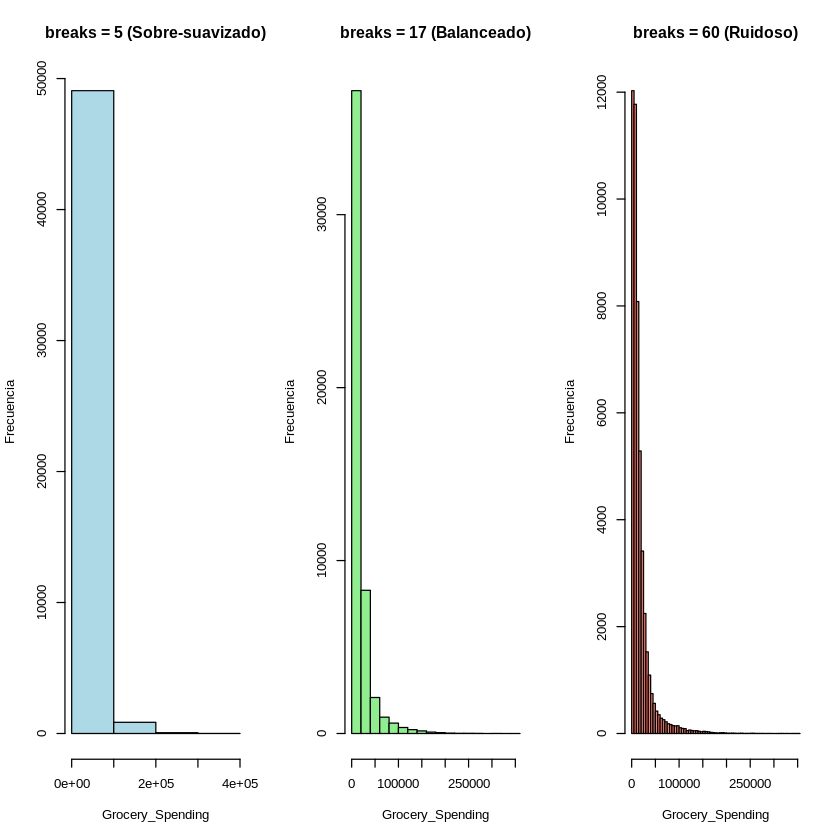

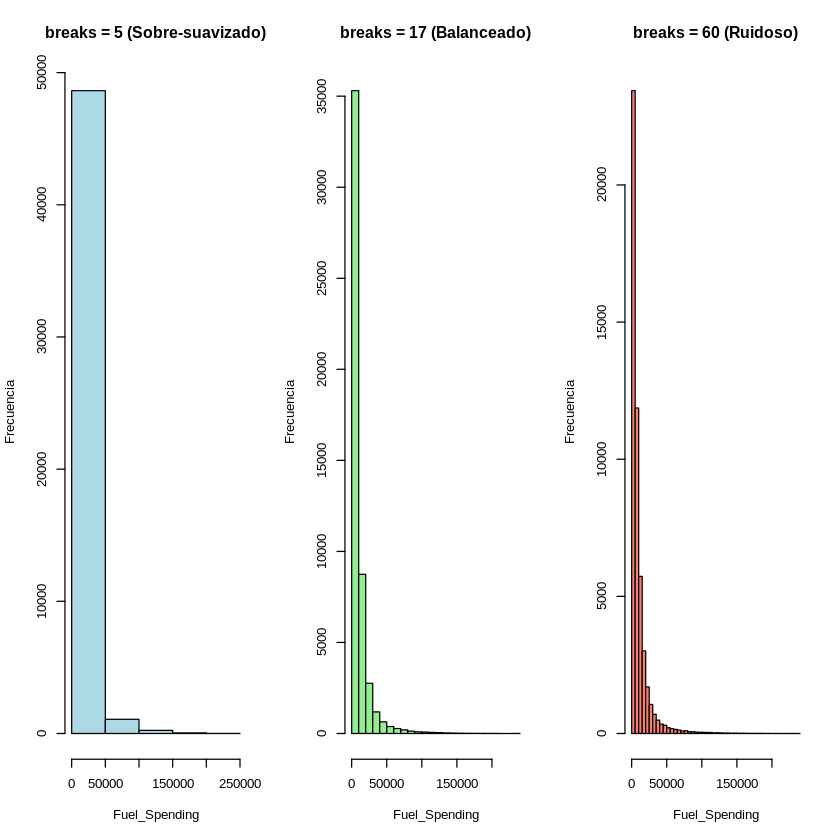

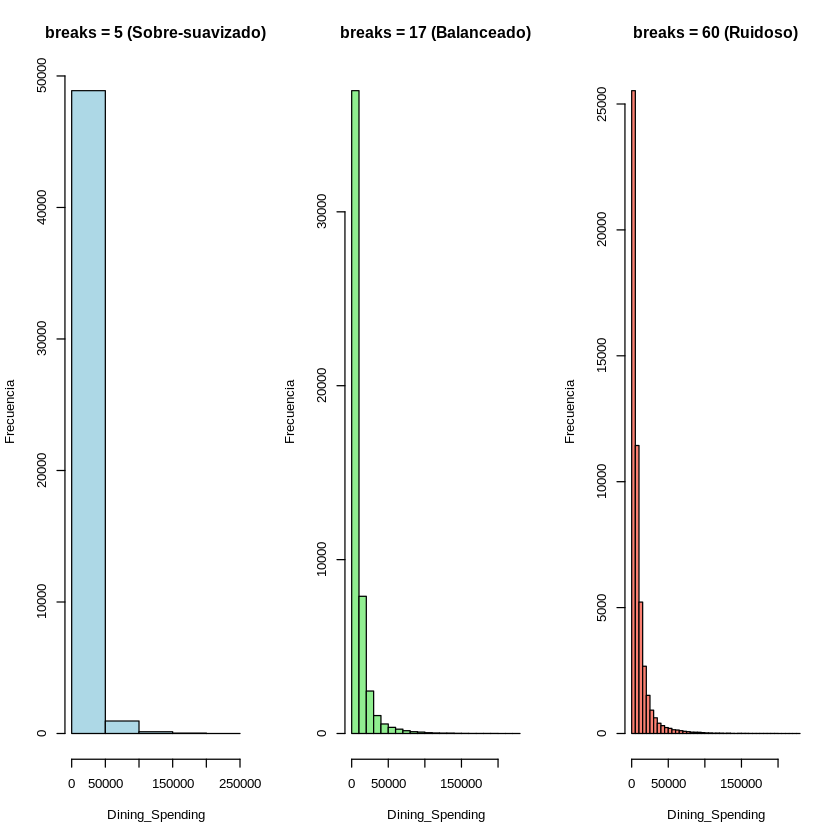

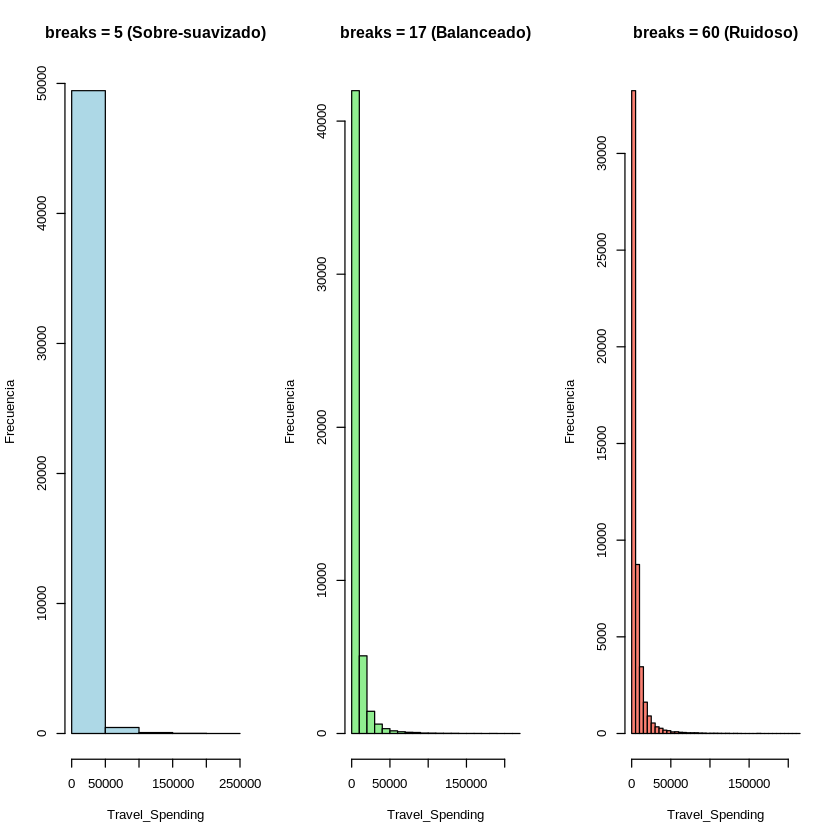

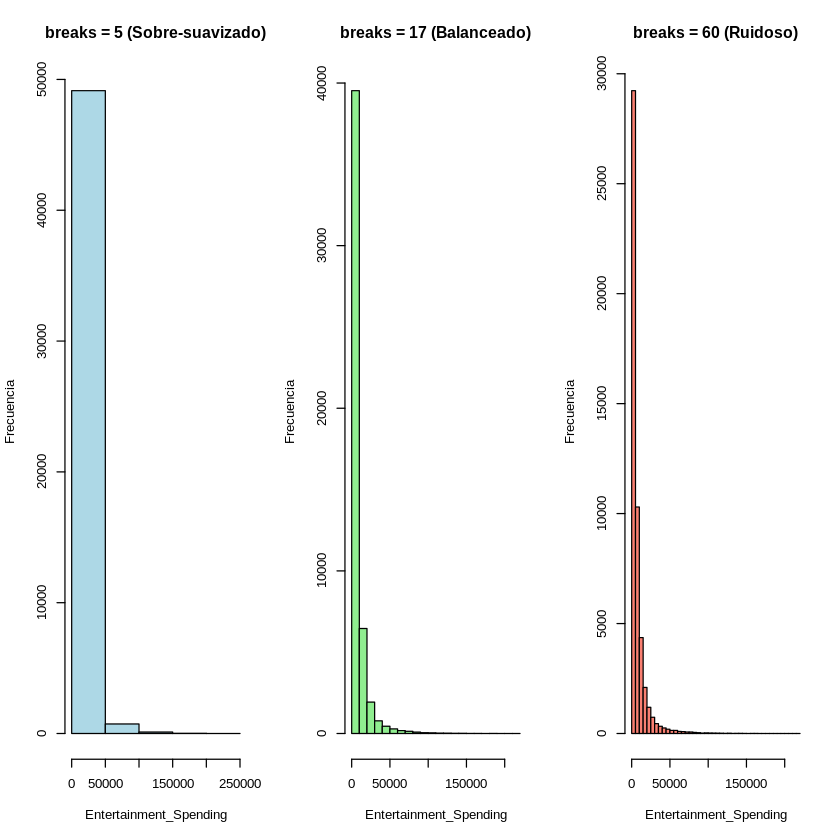

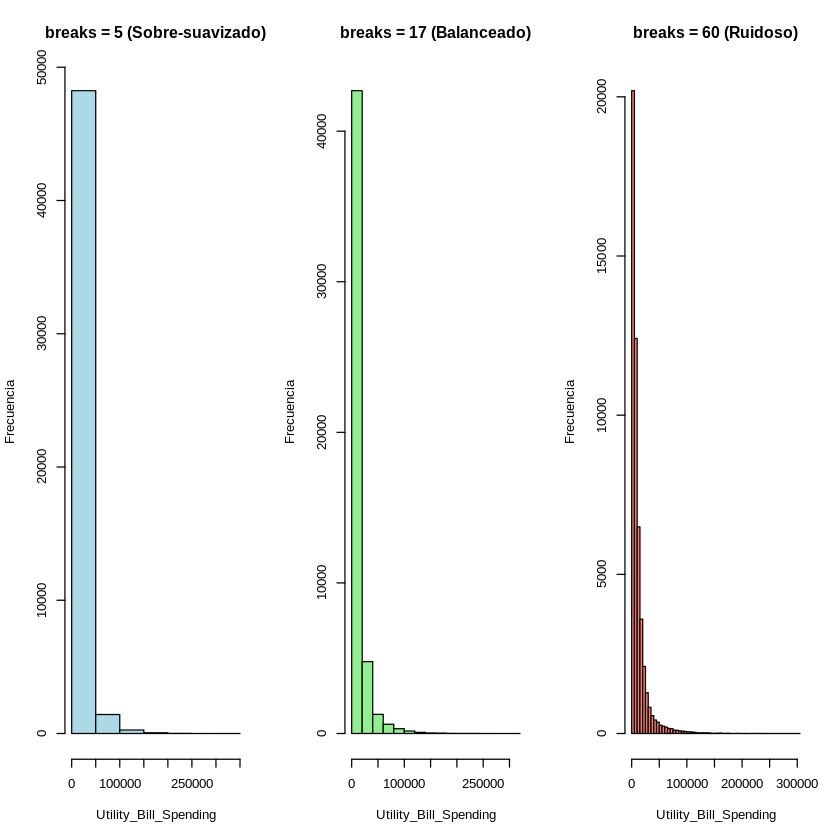

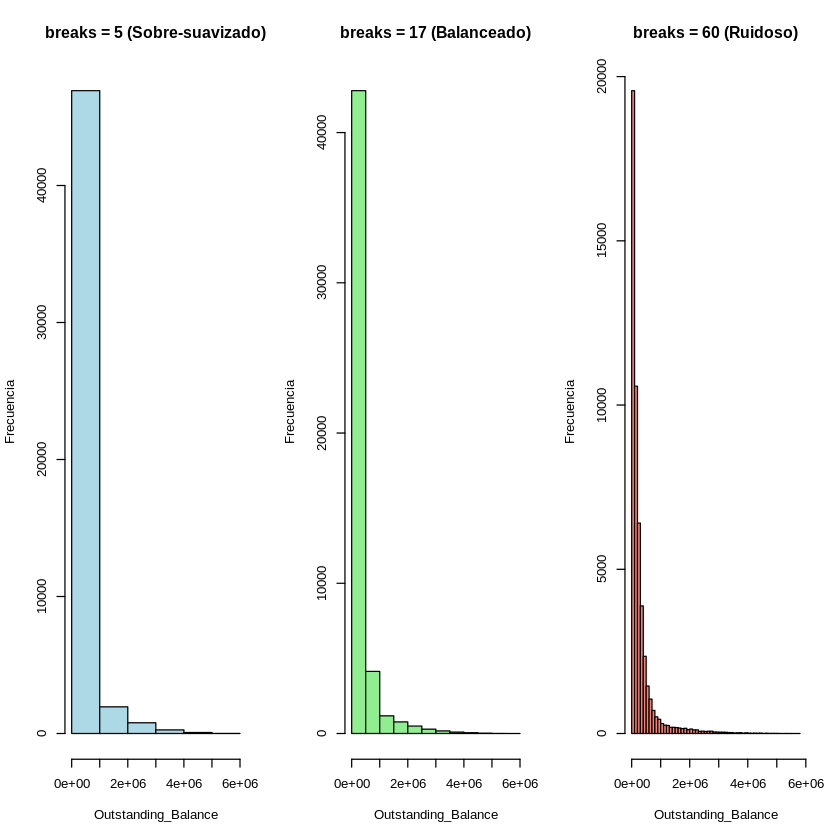

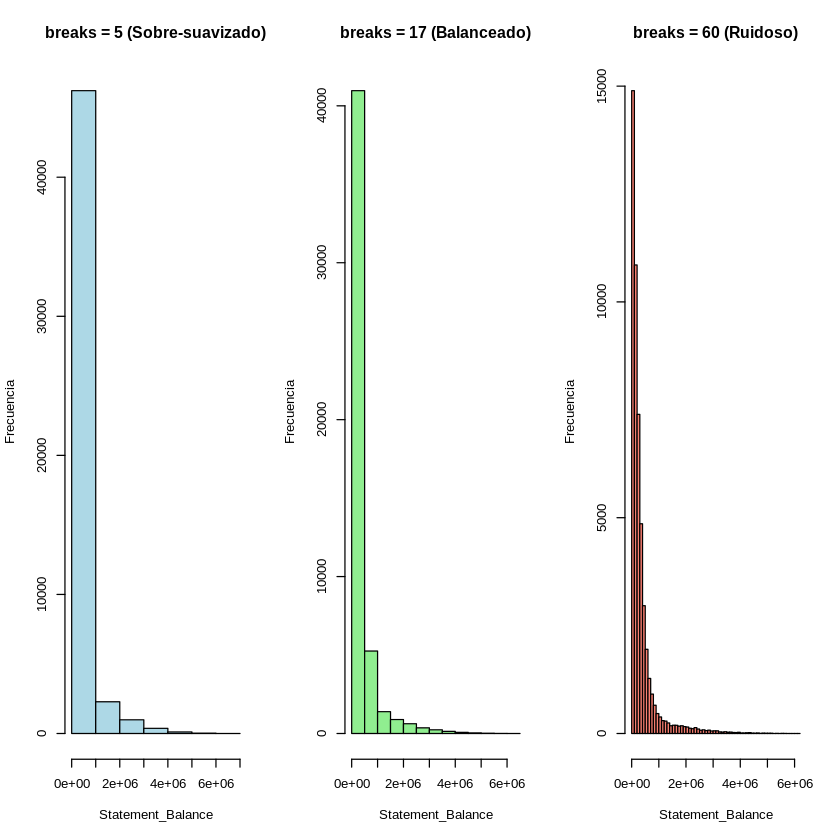

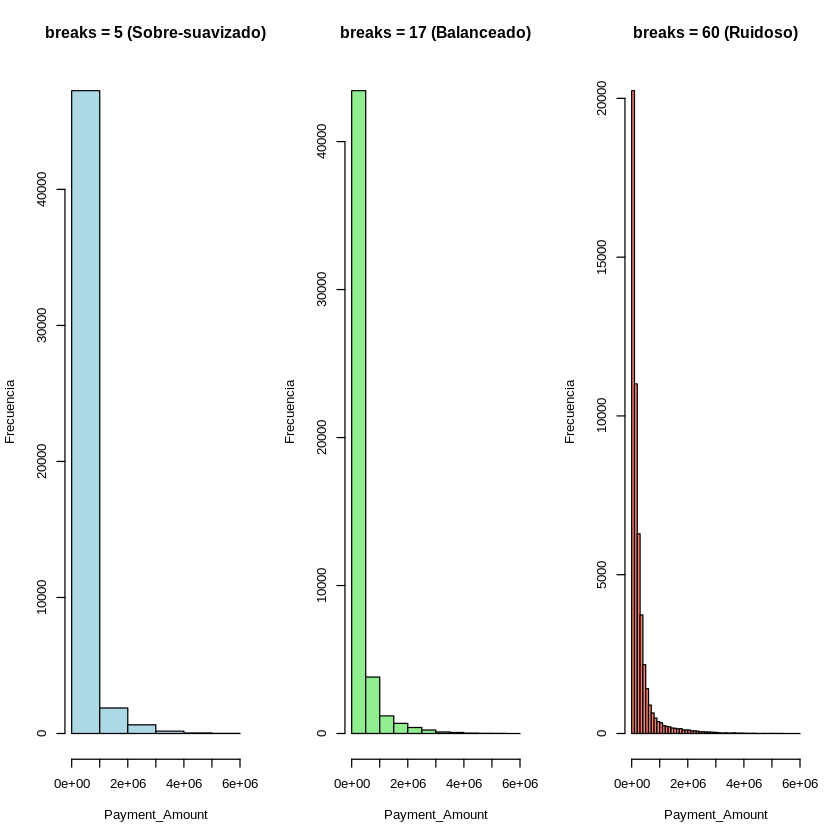

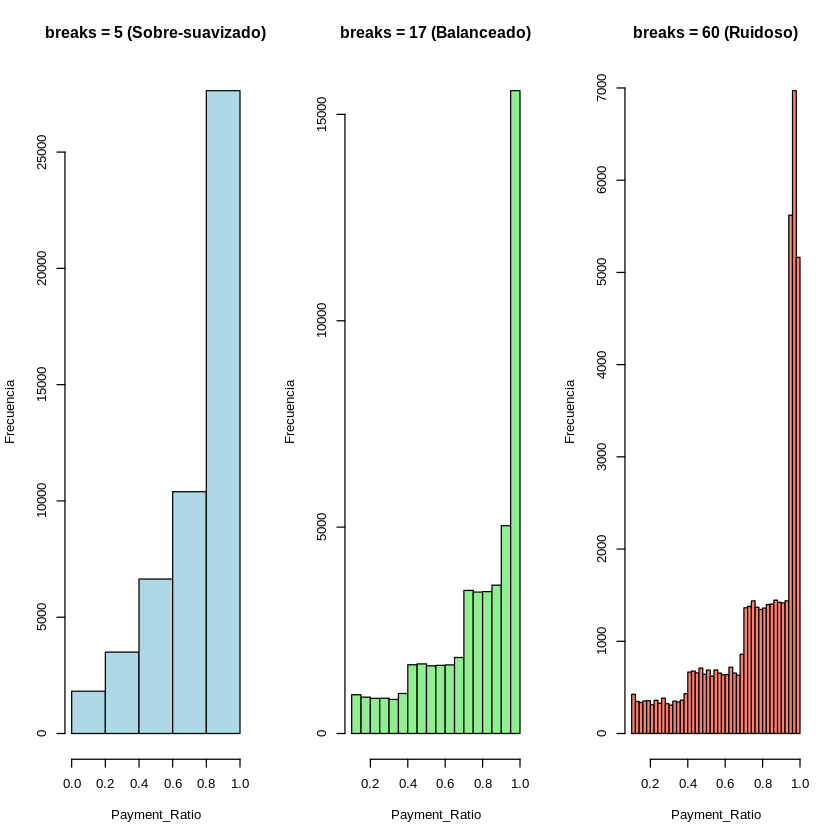

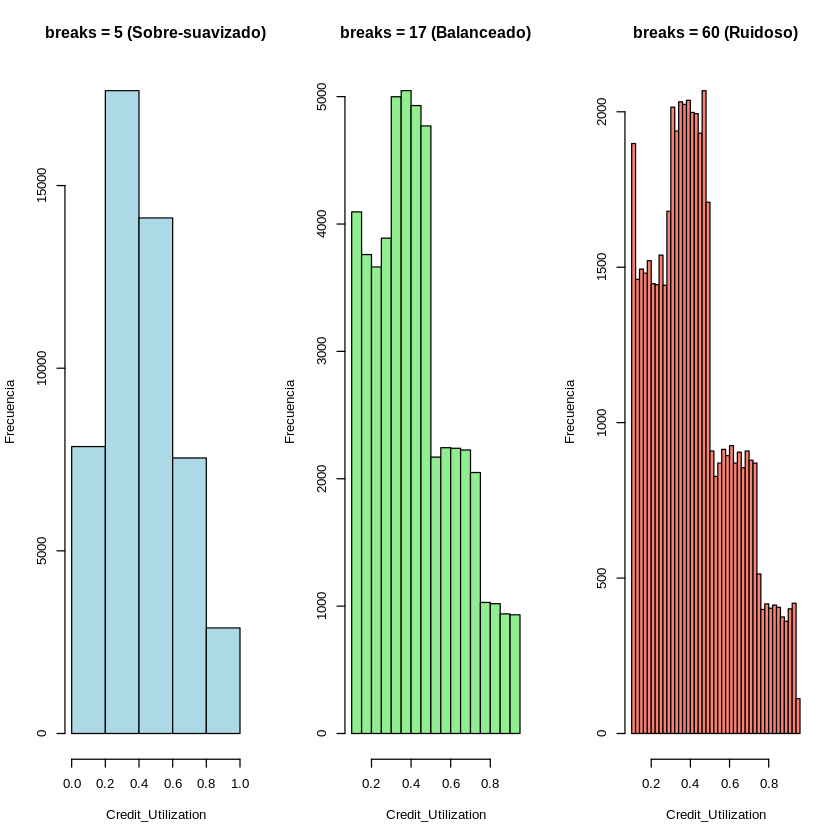

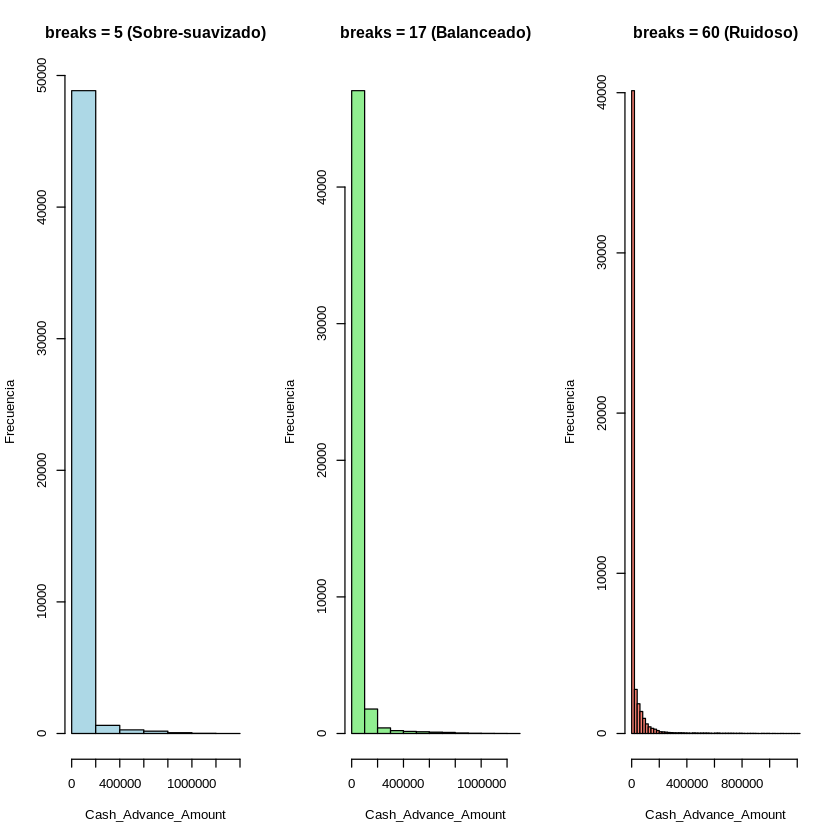

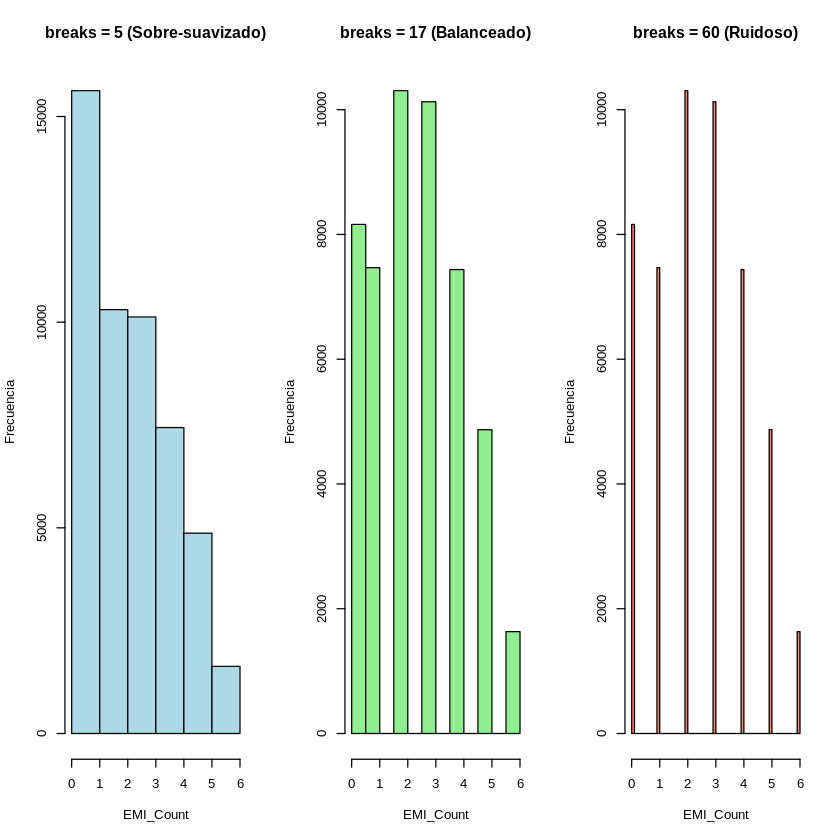

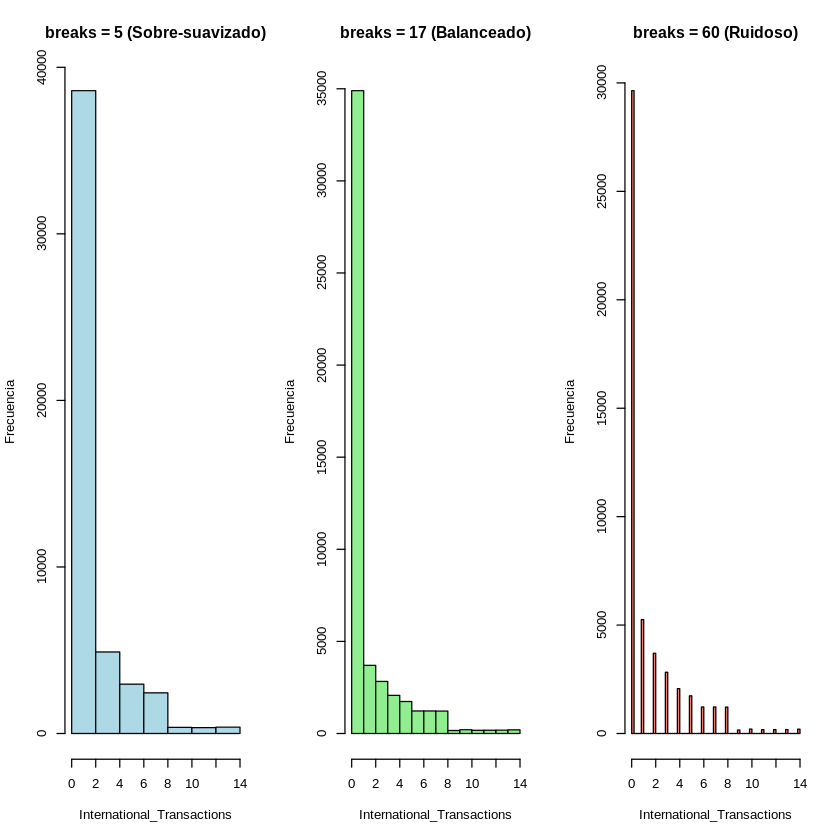

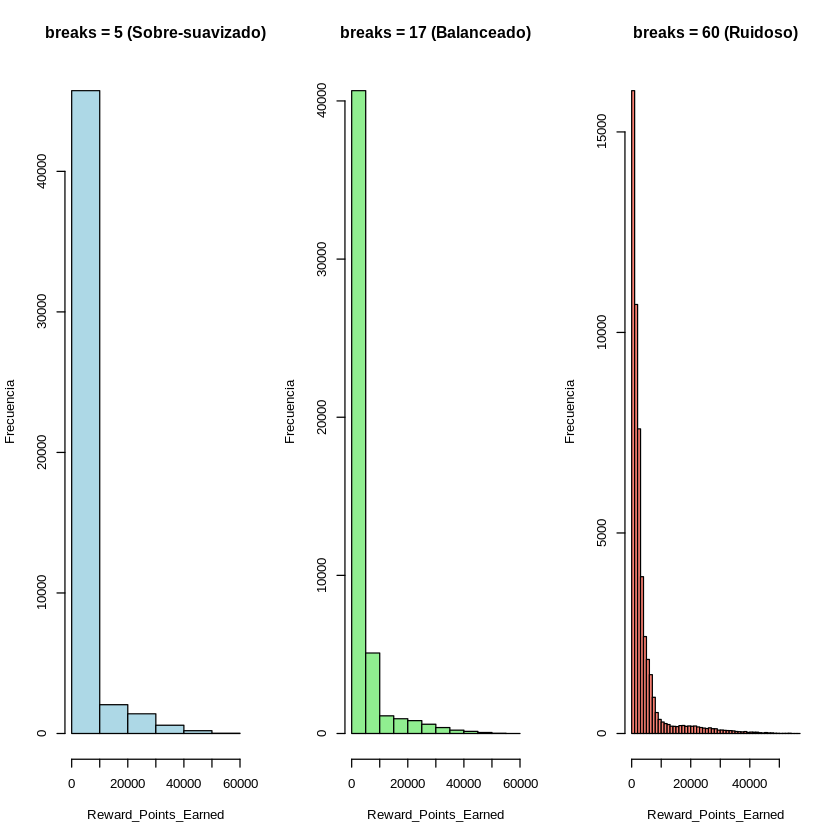

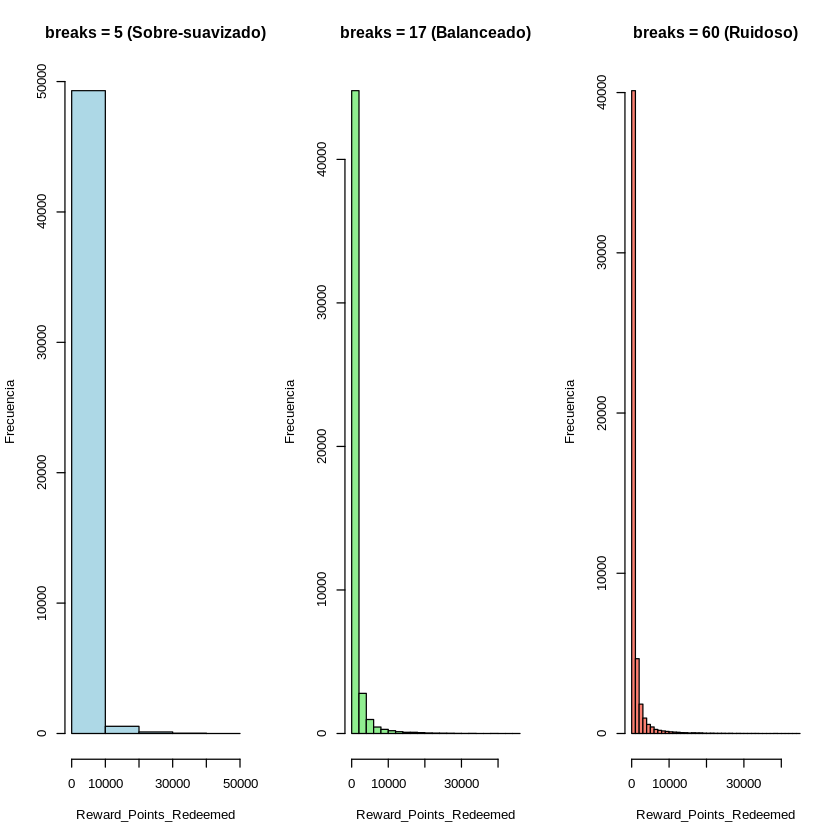

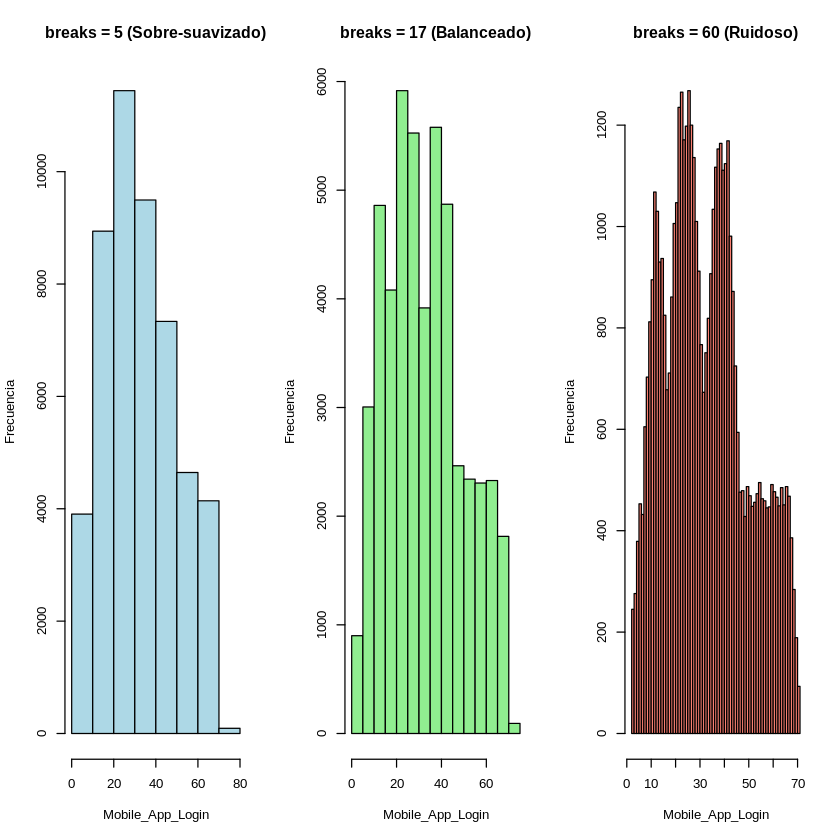

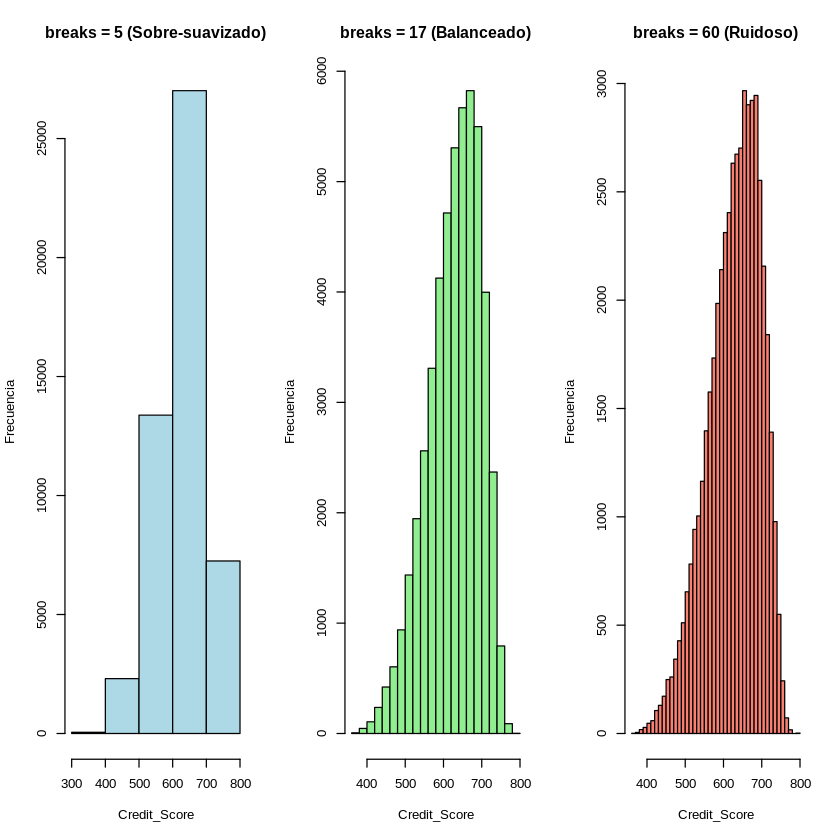

In [52]:
numeric_cols <- names(credit)[sapply(credit, is.numeric)]

for (col_name in numeric_cols) {
  # Get the vector for the current numeric column
  current_var <- credit[[col_name]]

  # Calculate Sturges' breaks for the current variable
  k_sturges <- nclass.Sturges(current_var)

  # Set up the plotting area for three histograms
  par(mfrow = c(1, 3))

  # Histogram with very few breaks (under-smoothed / underfitting)
  hist(current_var, breaks = 5, col = "lightblue", border = "black",
       main = paste("breaks = 5 (Sobre-suavizado)"),
       xlab = col_name, ylab = "Frecuencia")

  # Histogram with Sturges' breaks (balanced)
  hist(current_var, breaks = k_sturges, col = "lightgreen", border = "black",
       main = paste("breaks =", k_sturges, "(Balanceado)"),
       xlab = col_name, ylab = "Frecuencia")

  # Histogram with too many breaks (noisy / overfitting)
  hist(current_var, breaks = 60, col = "salmon", border = "black",
       main = paste("breaks = 60 (Ruidoso)"),
       xlab = col_name, ylab = "Frecuencia")

  # Reset plotting area
  par(mfrow = c(1, 1))
}

## Regla de Sturges

La regla de Sturges propone el número óptimo de intervalos para muestras bajo supuestos de normalidad:
$$k = 1 + \log_2(n) = 1 + 3.322 \cdot \log_{10}(n)$$

In [14]:
n_obs <- length(score)
k_sturges <- nclass.Sturges(score)
k_teorico <- 1 + log2(n_obs)

c(n = n_obs, k_Sturges = k_sturges, k_Formula = round(k_teorico, 2))

n k_Sturges k_Formula 
 50000.00     17.00     16.61

**Evaluación y decisión:**
Para $n = `r n_obs`$, Sturges sugiere $k = `r k_sturges`$ intervalos. El histograma con `breaks = 20` captura la forma unimodal simétrica de los puntajes crediticios sin introducir picos artificiales causados por la variabilidad muestral fina.

---

# Módulo 4: Caja y Bigotes (Boxplots) y Detección Univariada de Atípicos (S03)

## Los cinco números de Tukey (`fivenum`)

Analizamos el gasto mensual (`Monthly_Spending`):

In [44]:
gasto <- credit$Monthly_Spending
f_gasto <- fivenum(gasto)
names(f_gasto) <- c("Mínimo", "Q1", "Mediana", "Q3", "Máximo")
f_gasto

Mínimo        Q1   Mediana        Q3    Máximo 
  2235.63  26646.33  50022.38  83032.36 691687.96

In [45]:
ingreso <- credit$Annual_Income
f_ingreso <- fivenum(ingreso)
names(f_ingreso) <- c("Mínimo", "Q1", "Mediana", "Q3", "Máximo")
f_ingreso

Mínimo        Q1   Mediana        Q3    Máximo 
 100050.0  657770.5 1127629.5 1663677.0 7995831.0

## Rango Intercuartílico ($RIC$) y Límites de Tukey

El criterio de Tukey define las barreras para valores atípicos (*outliers*) como:
$$\text{Límite Inferior} = Q_1 - 1.5 \cdot RIC$$
$$\text{Límite Superior} = Q_3 + 1.5 \cdot RIC$$

In [46]:
q1_gasto <- f_gasto["Q1"]
q3_gasto <- f_gasto["Q3"]
ric_gasto <- q3_gasto - q1_gasto

lim_inf_gasto <- q1_gasto - 1.5 * ric_gasto
lim_sup_gasto <- q3_gasto + 1.5 * ric_gasto

c(Q1 = q1_gasto, Q3 = q3_gasto, RIC = ric_gasto,
  Lim_Inferior = lim_inf_gasto, Lim_Superior = lim_sup_gasto)

Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       26646.33        83032.36        56386.03       -57932.71       167611.40

## Conteo de atípicos univariados

In [48]:
atipicos_gasto <- gasto[gasto < lim_inf_gasto | gasto > lim_sup_gasto]
n_atipicos_gasto <- length(atipicos_gasto)
pct_atipicos_gasto <- (n_atipicos_gasto / length(gasto)) * 100

c(N_Atipicos = n_atipicos_gasto, Porcentaje = round(pct_atipicos_gasto, 3))

N_Atipicos Porcentaje 
  4213.000      8.426

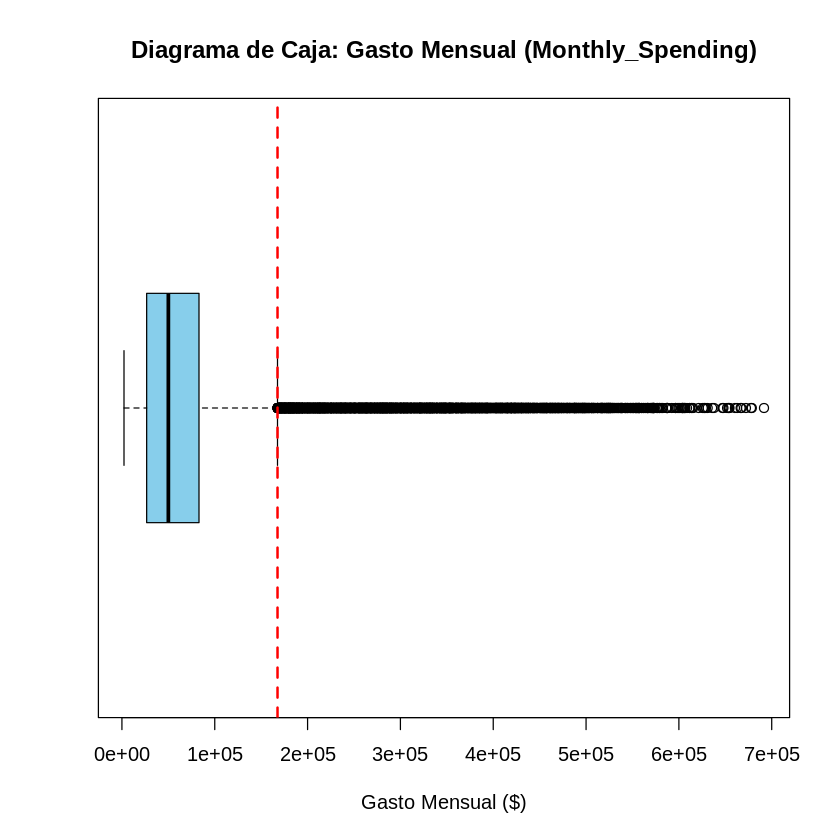

In [50]:
boxplot(gasto, horizontal = TRUE, col = "skyblue",
        main = "Diagrama de Caja: Gasto Mensual (Monthly_Spending)",
        xlab = "Gasto Mensual ($)")
abline(v = c(lim_inf_gasto, lim_sup_gasto), col = "red", lty = 2, lwd = 2)

--------------------------------------------------
Análisis para la variable:  Age 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
           27.0            44.0            17.0             1.5            69.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   278.000      0.556 


--------------------------------------------------
Análisis para la variable:  Annual_Income 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       657770.5       1663677.0       1005906.5       -851089.2       3172536.8 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4037.000      8.074 


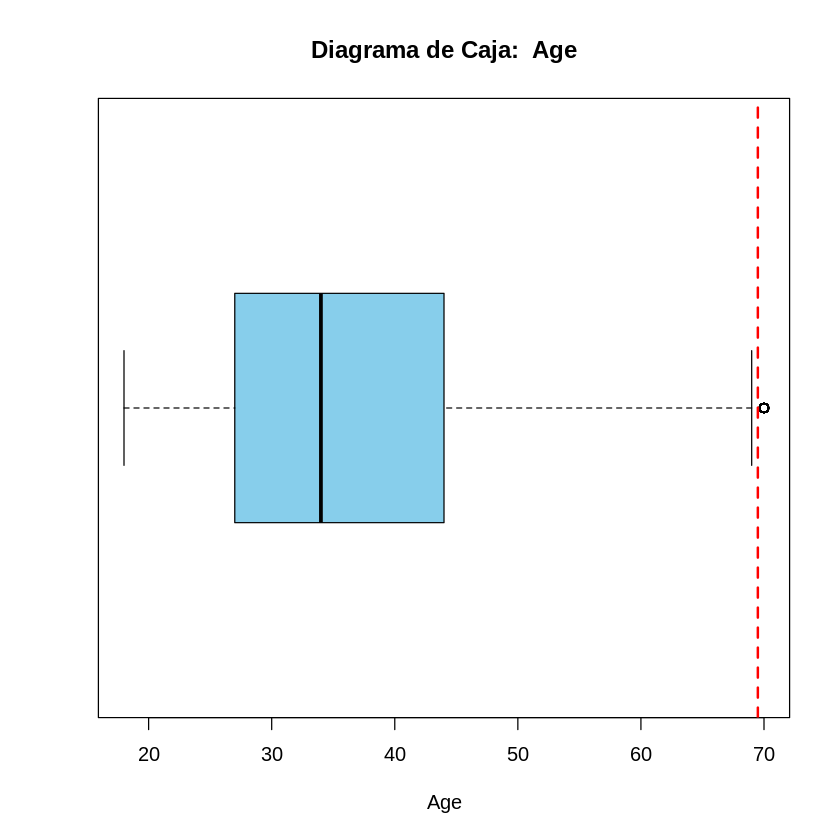



--------------------------------------------------
Análisis para la variable:  Credit_Limit 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
         157000          779000          622000         -776000         1712000 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4173.000      8.346 


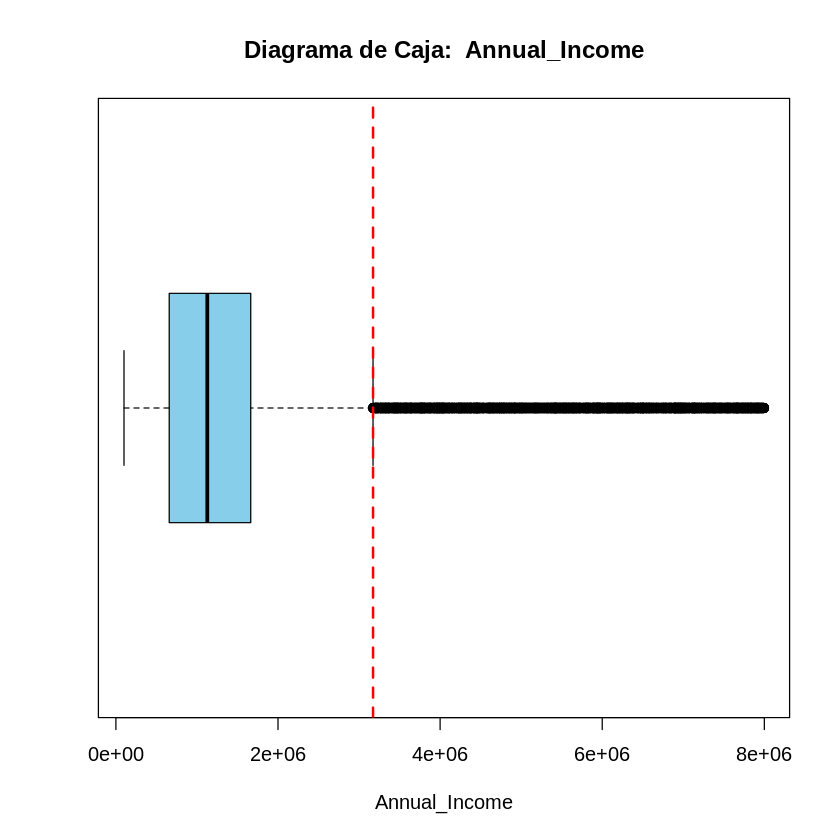



--------------------------------------------------
Análisis para la variable:  Card_Age_Months 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
           31.0            70.0            39.0           -27.5           128.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  1287.000      2.574 


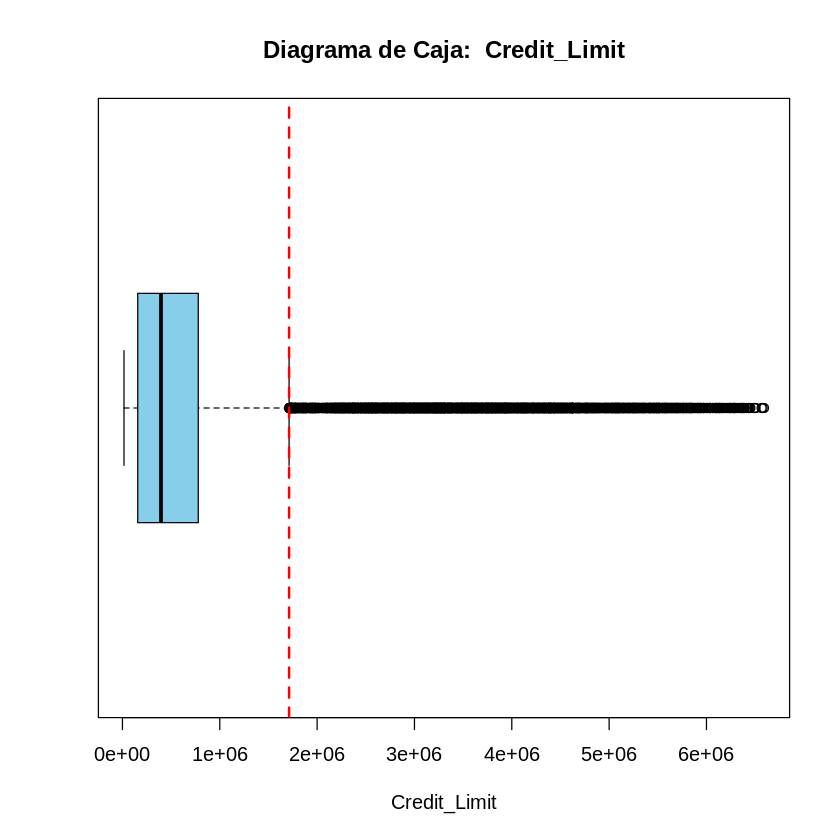



--------------------------------------------------
Análisis para la variable:  Monthly_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       26646.33        83032.36        56386.03       -57932.71       167611.40 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4213.000      8.426 


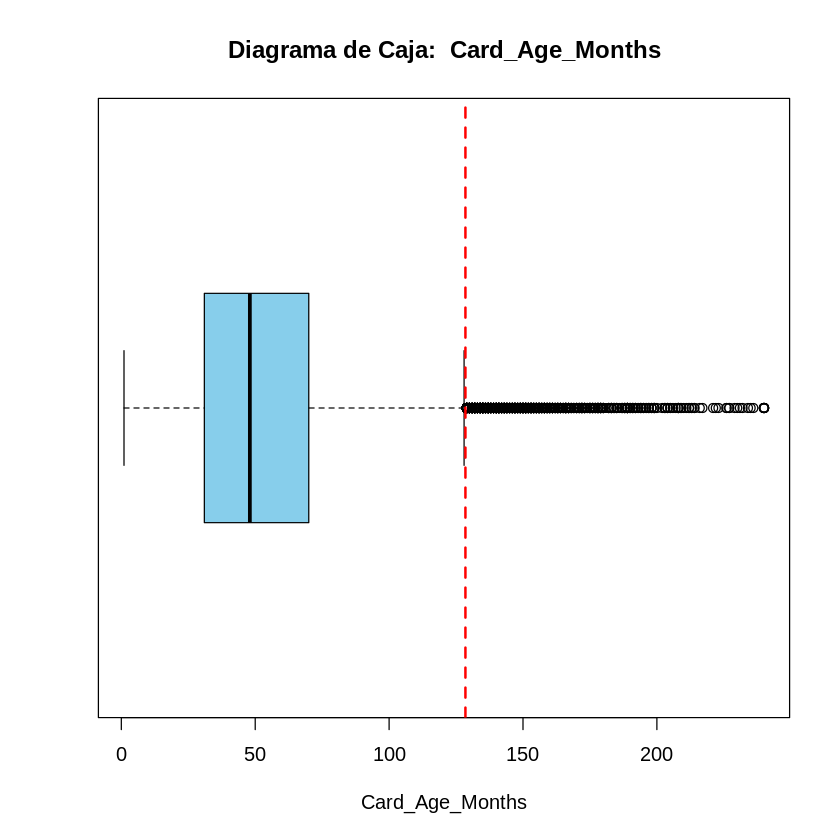



--------------------------------------------------
Análisis para la variable:  Monthly_Transactions 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
           49.0           108.0            59.0           -39.5           196.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
         0          0 


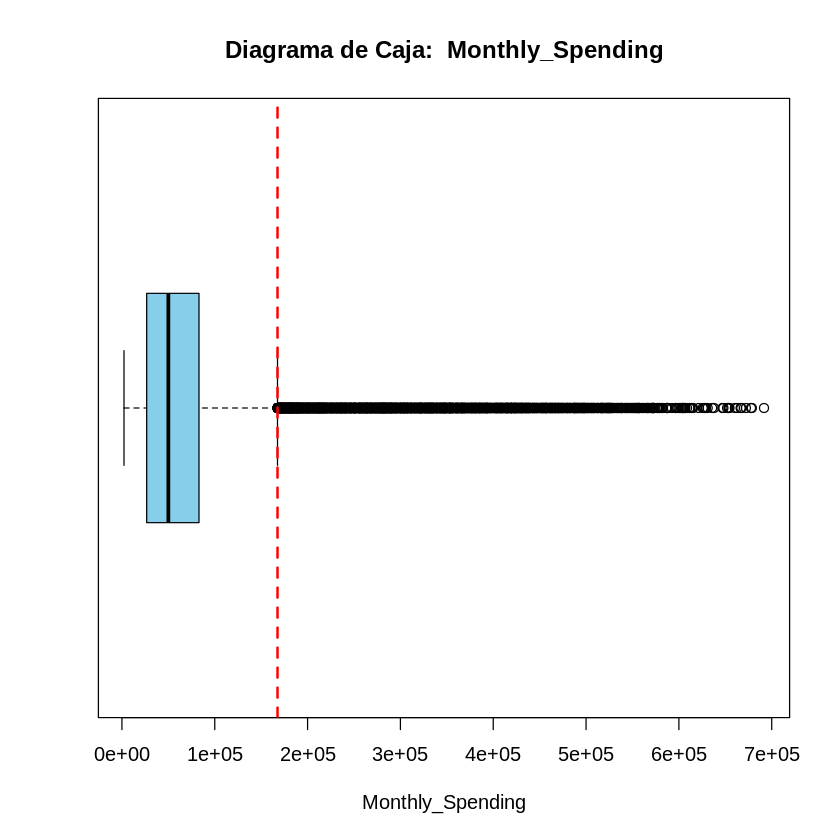



--------------------------------------------------
Análisis para la variable:  Avg_Transaction_Value 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
         448.37          901.27          452.90         -230.98         1580.62 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4286.000      8.572 


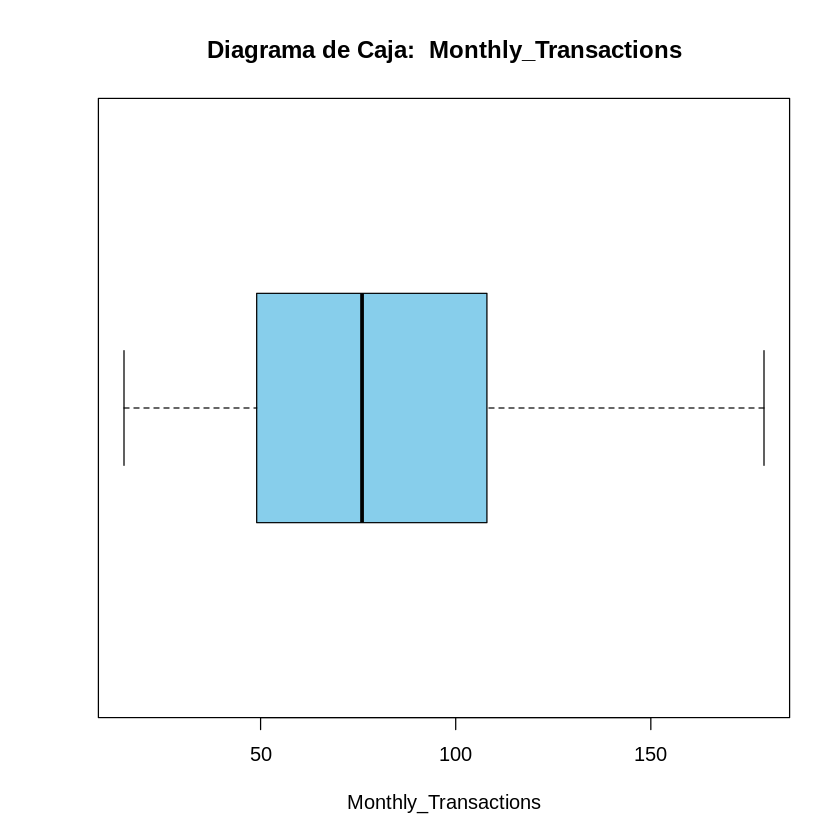



--------------------------------------------------
Análisis para la variable:  Online_Shopping_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       2800.675       12820.420       10019.745      -12228.942       27850.037 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   4045.00       8.09 


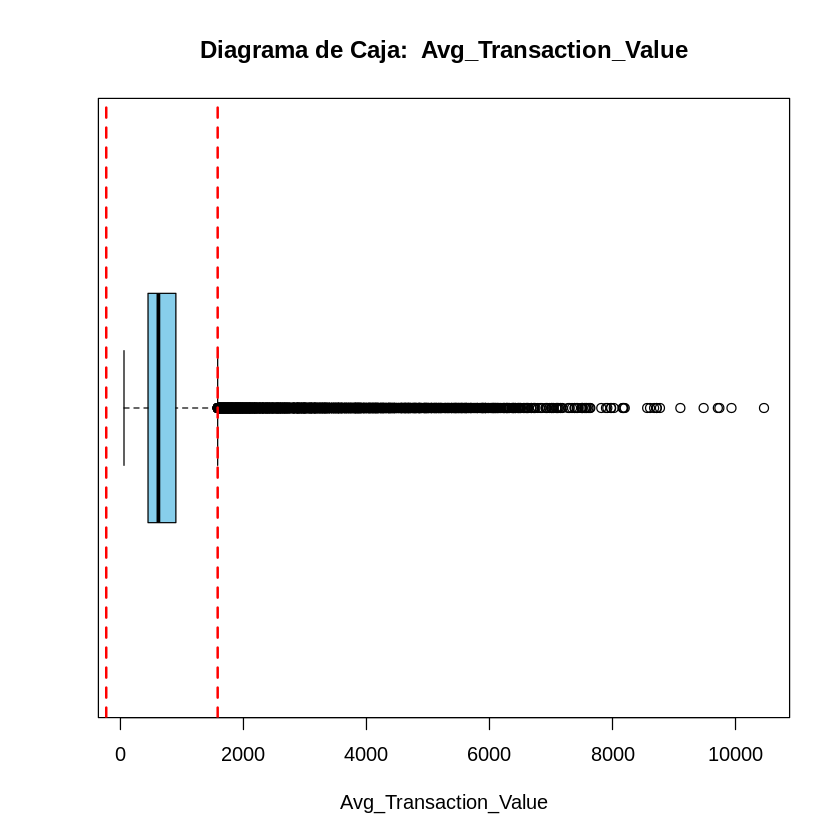



--------------------------------------------------
Análisis para la variable:  Grocery_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       5176.815       20419.725       15242.910      -17687.550       43284.090 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4032.000      8.064 


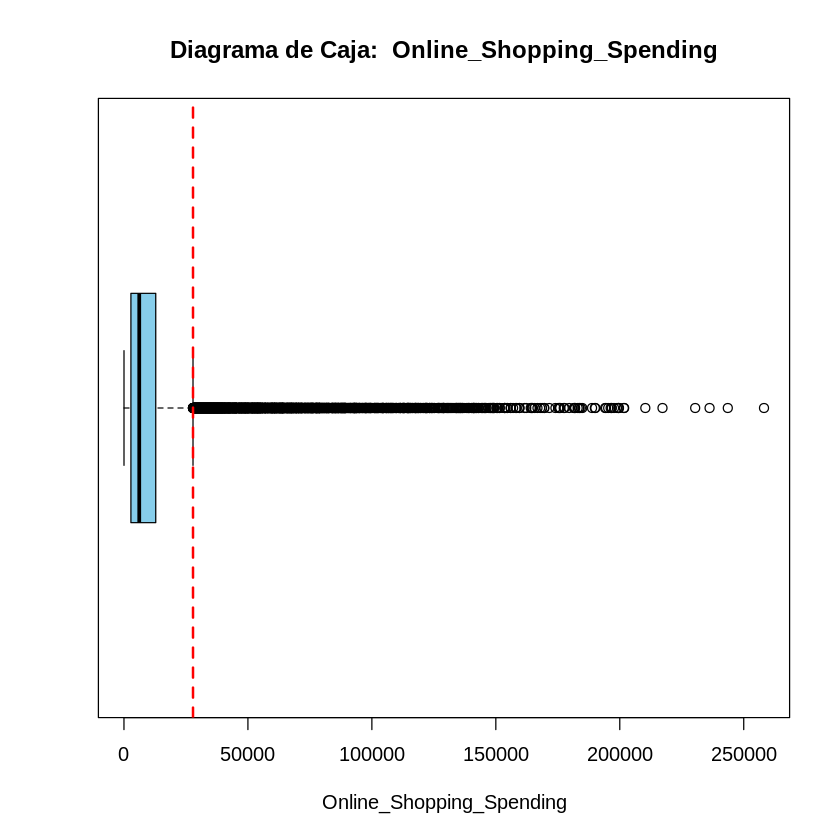



--------------------------------------------------
Análisis para la variable:  Fuel_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       2432.140       11560.985        9128.845      -11261.128       25254.253 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4176.000      8.352 


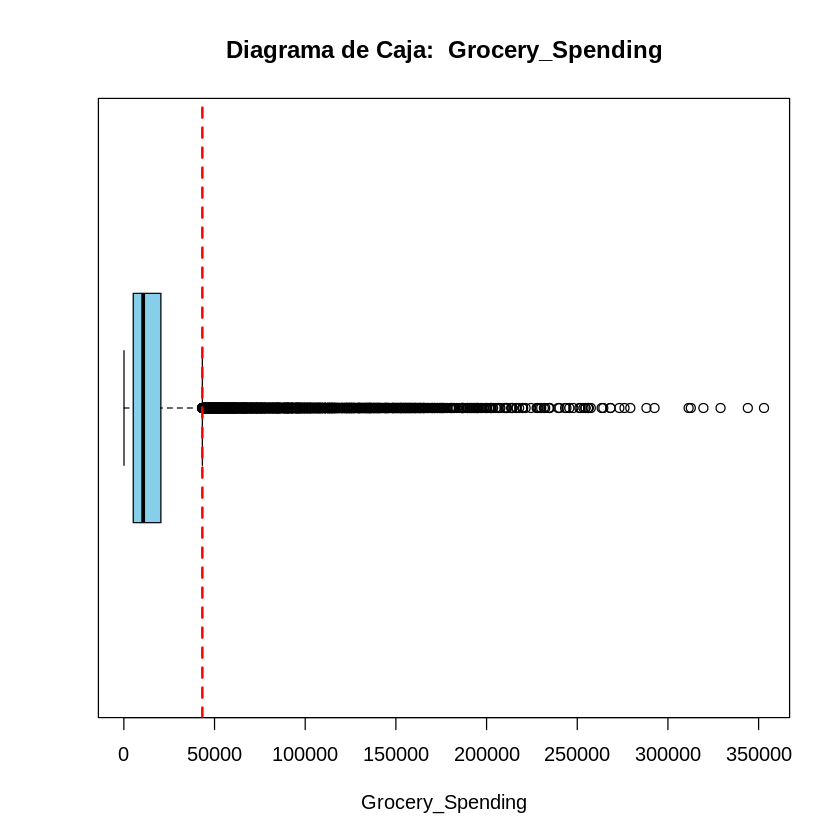



--------------------------------------------------
Análisis para la variable:  Dining_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       2089.505       10381.865        8292.360      -10349.035       22820.405 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4202.000      8.404 


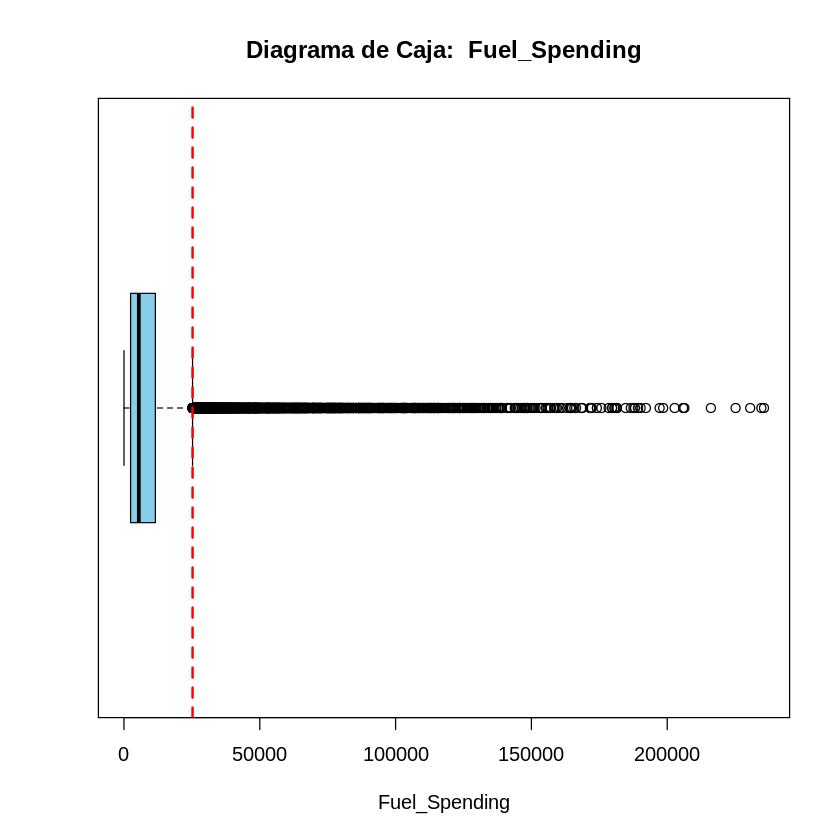



--------------------------------------------------
Análisis para la variable:  Travel_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       1076.960        6862.885        5785.925       -7601.928       15541.773 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   4315.00       8.63 


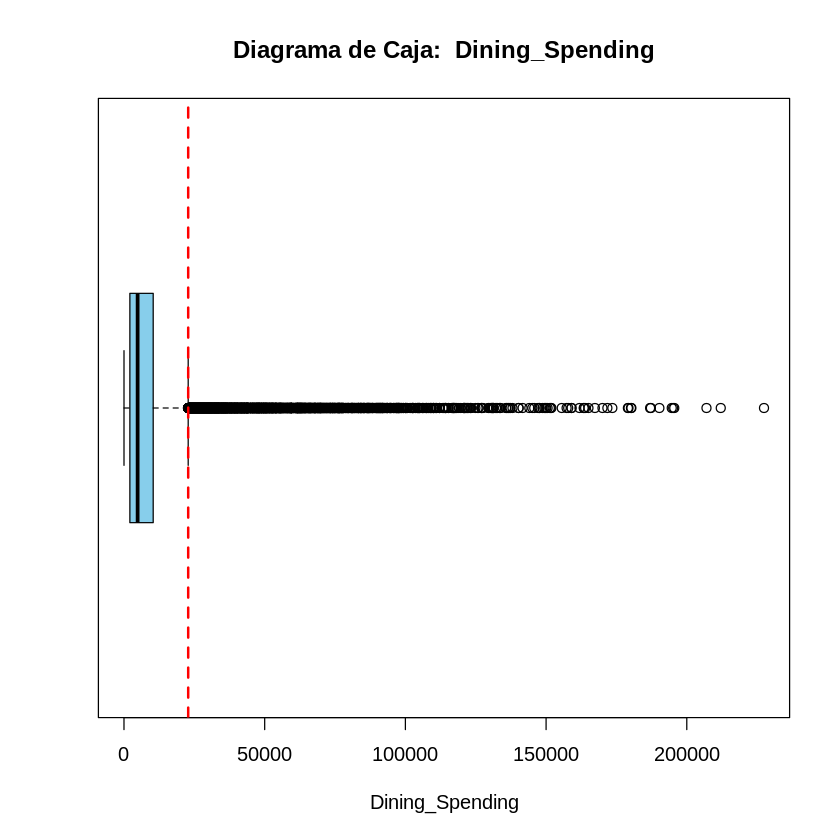



--------------------------------------------------
Análisis para la variable:  Entertainment_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       1570.085        8612.840        7042.755       -8994.048       19176.972 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4276.000      8.552 


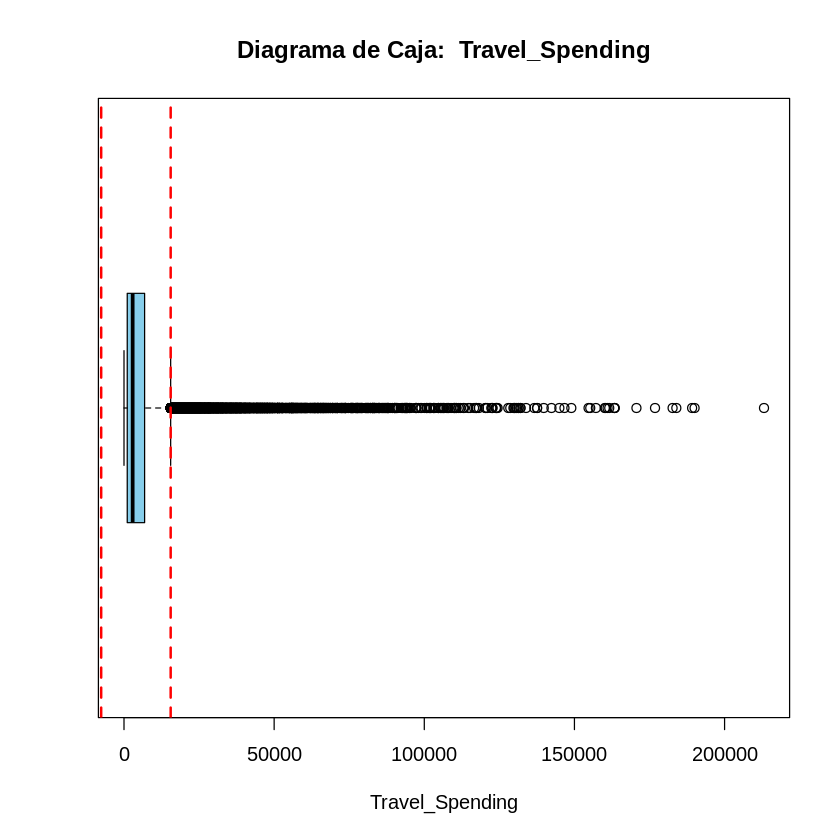



--------------------------------------------------
Análisis para la variable:  Utility_Bill_Spending 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
        2978.38        13510.05        10531.67       -12819.12        29307.54 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4056.000      8.112 


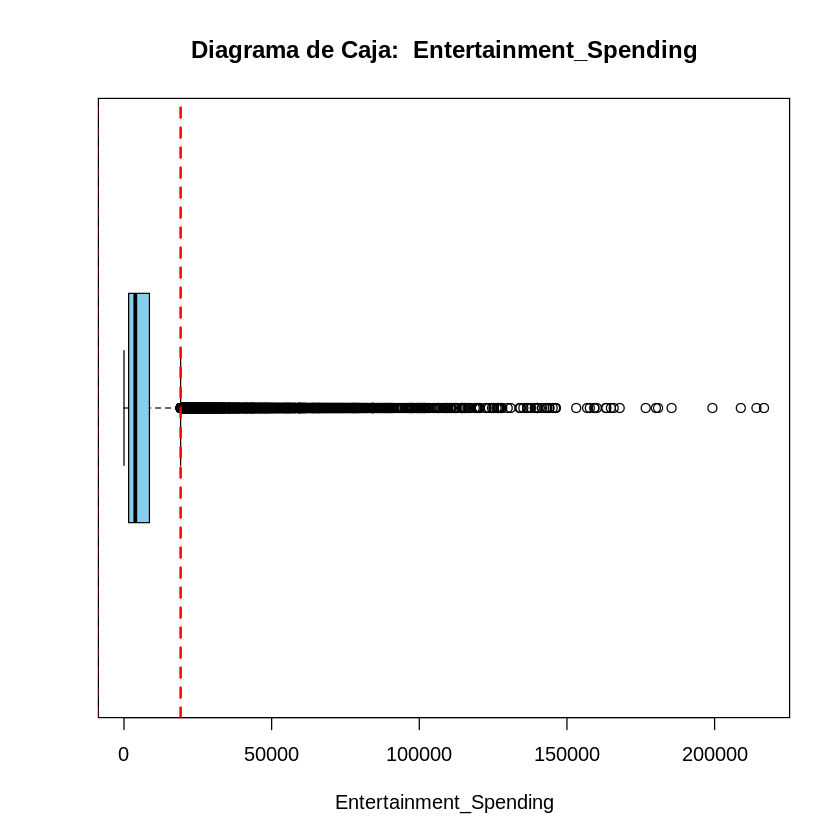



--------------------------------------------------
Análisis para la variable:  Outstanding_Balance 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       55640.71       319985.76       264345.05      -340876.85       716503.33 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   4570.00       9.14 


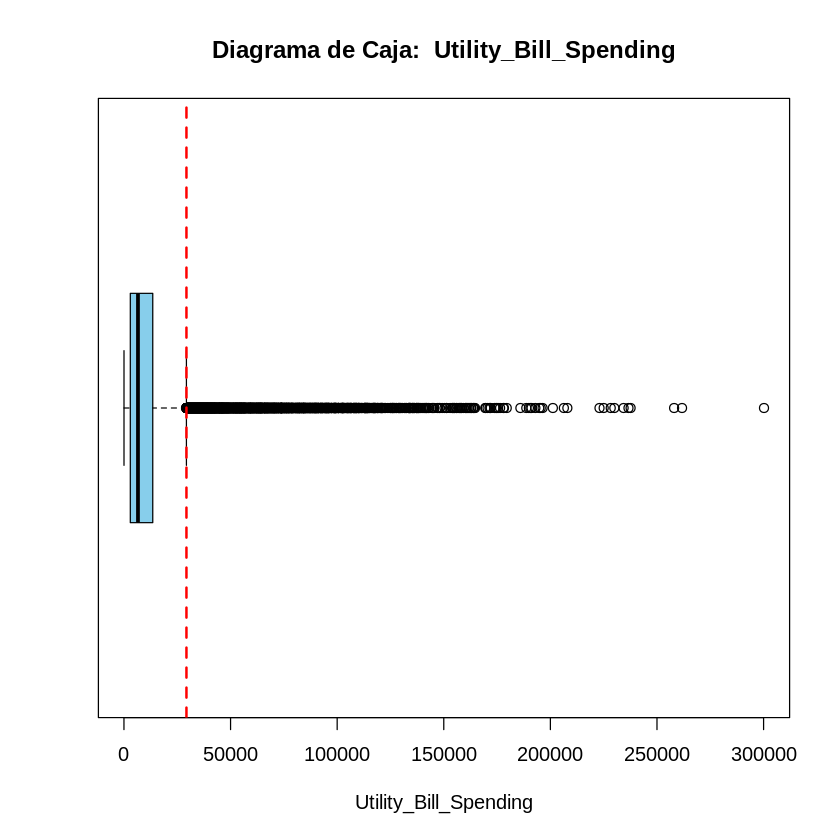



--------------------------------------------------
Análisis para la variable:  Statement_Balance 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
        82467.3        387442.0        304974.7       -374994.8        844904.1 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4591.000      9.182 


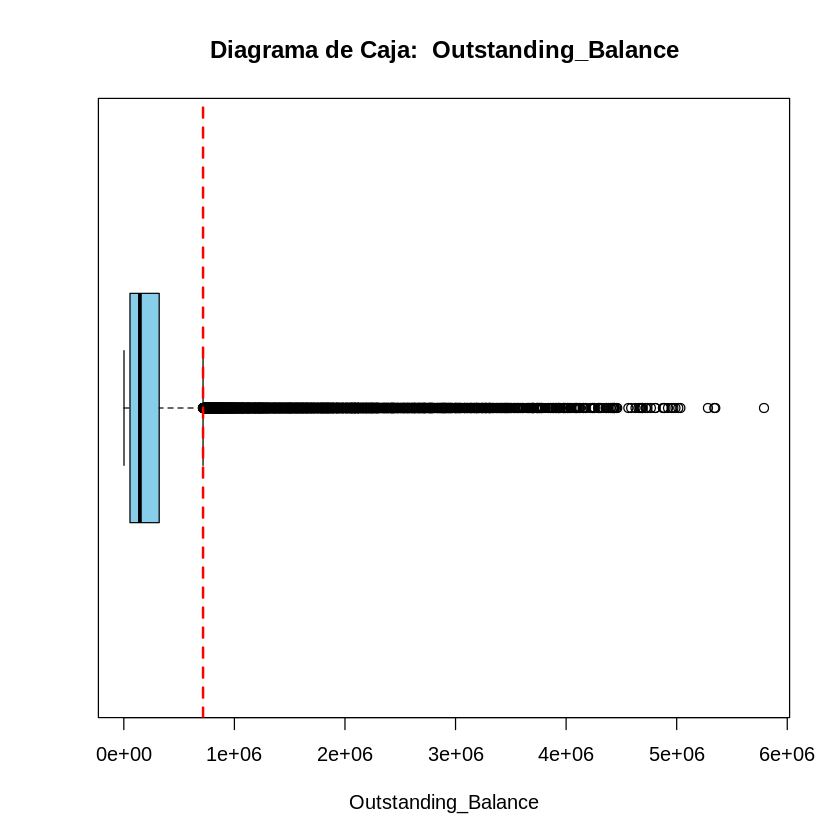



--------------------------------------------------
Análisis para la variable:  Payment_Amount 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       55193.18       299100.96       243907.77      -310668.47       664962.61 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   4535.00       9.07 


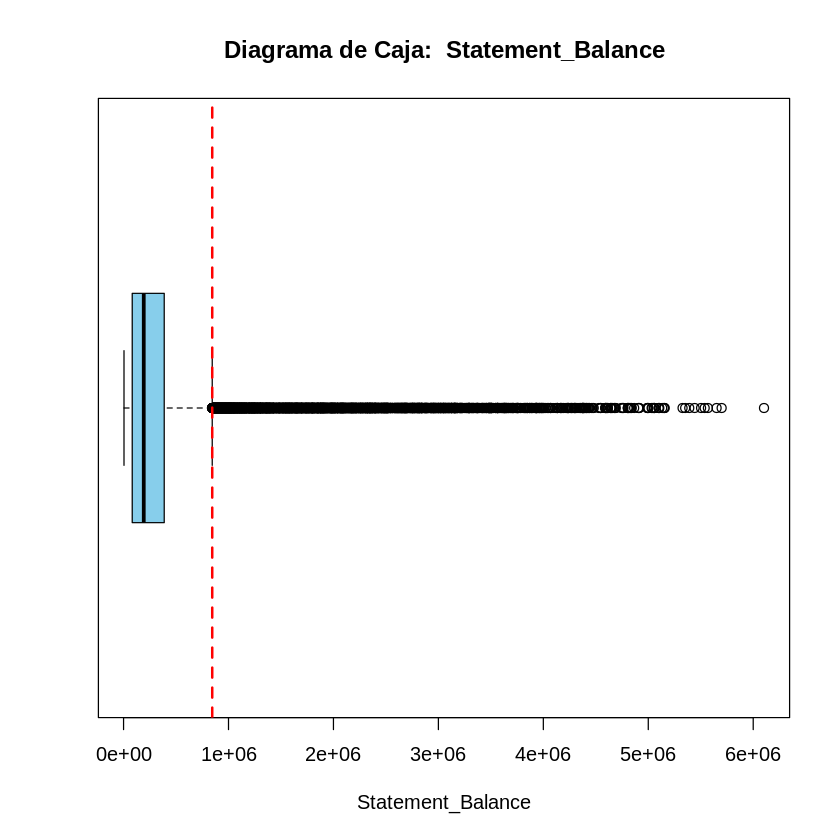



--------------------------------------------------
Análisis para la variable:  Payment_Ratio 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
           0.62            0.96            0.34            0.11            1.47 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
    87.000      0.174 


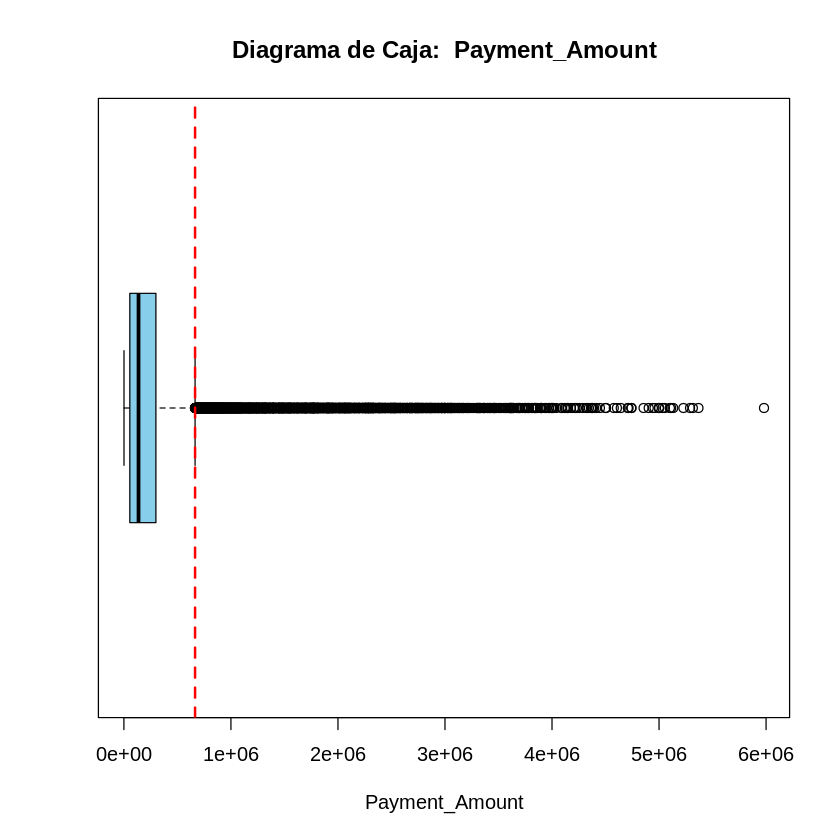



--------------------------------------------------
Análisis para la variable:  Credit_Utilization 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
          0.270           0.560           0.290          -0.165           0.995 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
         0          0 


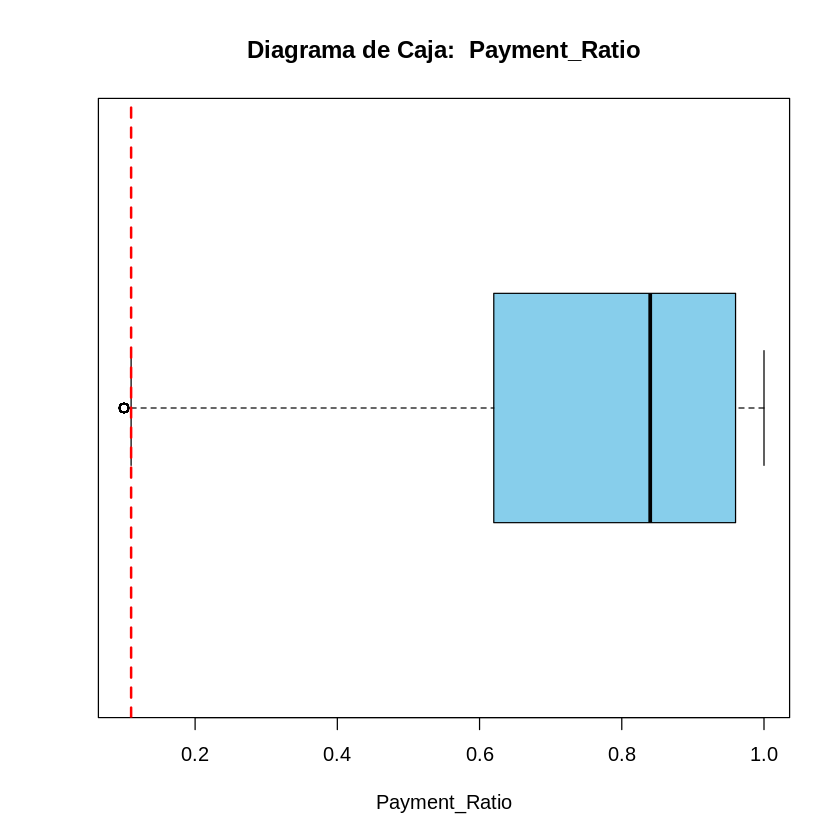



--------------------------------------------------
Análisis para la variable:  Cash_Advance_Amount 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
           0.00         8692.19         8692.19       -13038.28        21730.47 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  9549.000     19.098 


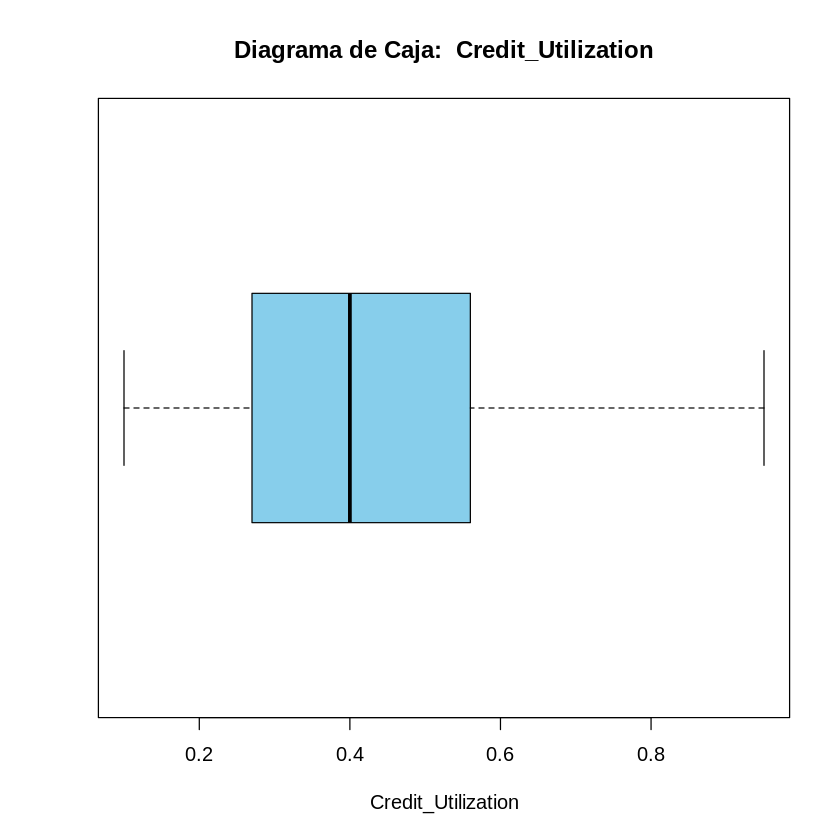



--------------------------------------------------
Análisis para la variable:  EMI_Count 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
            1.0             4.0             3.0            -3.5             8.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
         0          0 


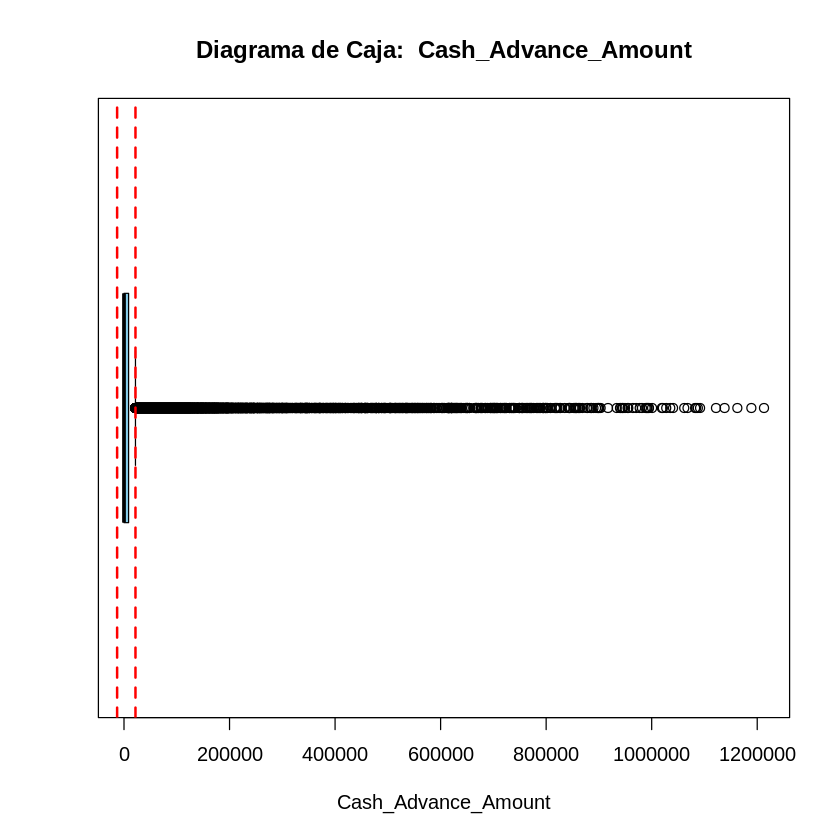



--------------------------------------------------
Análisis para la variable:  International_Transactions 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
              0               2               2              -3               5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  4769.000      9.538 


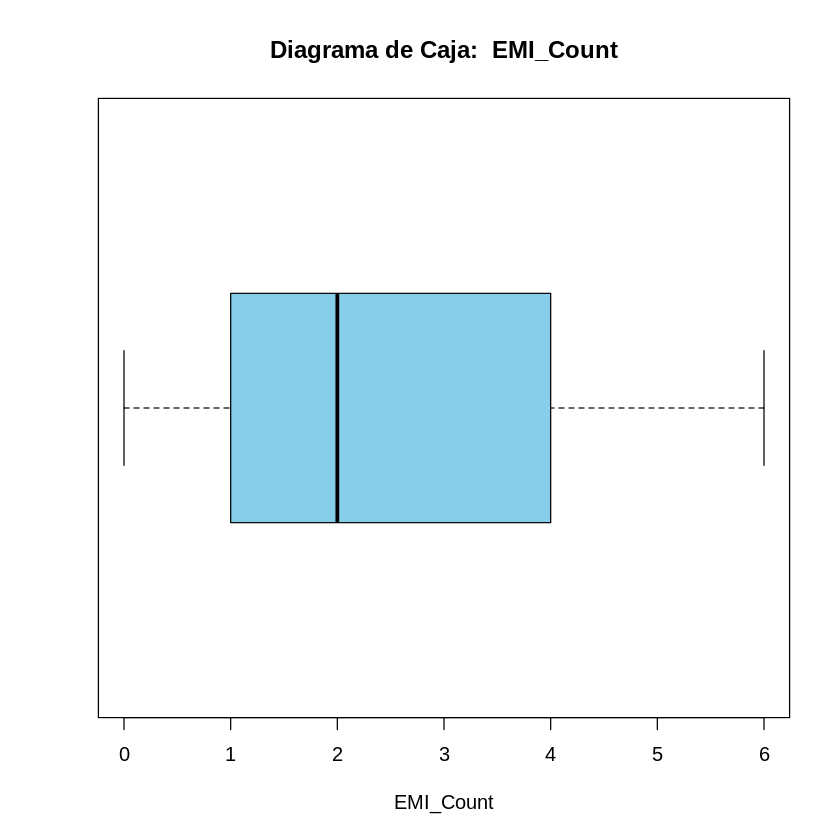



--------------------------------------------------
Análisis para la variable:  Reward_Points_Earned 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
          720.0          3767.0          3047.0         -3850.5          8337.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   4930.00       9.86 


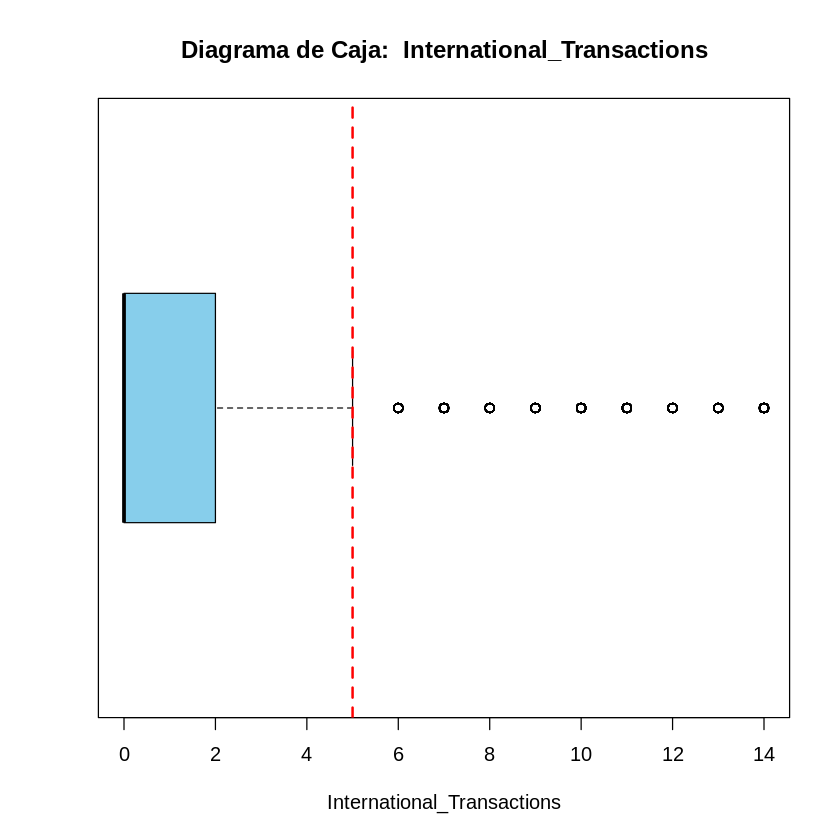



--------------------------------------------------
Análisis para la variable:  Reward_Points_Redeemed 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
            0.0           731.0           731.0         -1096.5          1827.5 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
  5708.000     11.416 


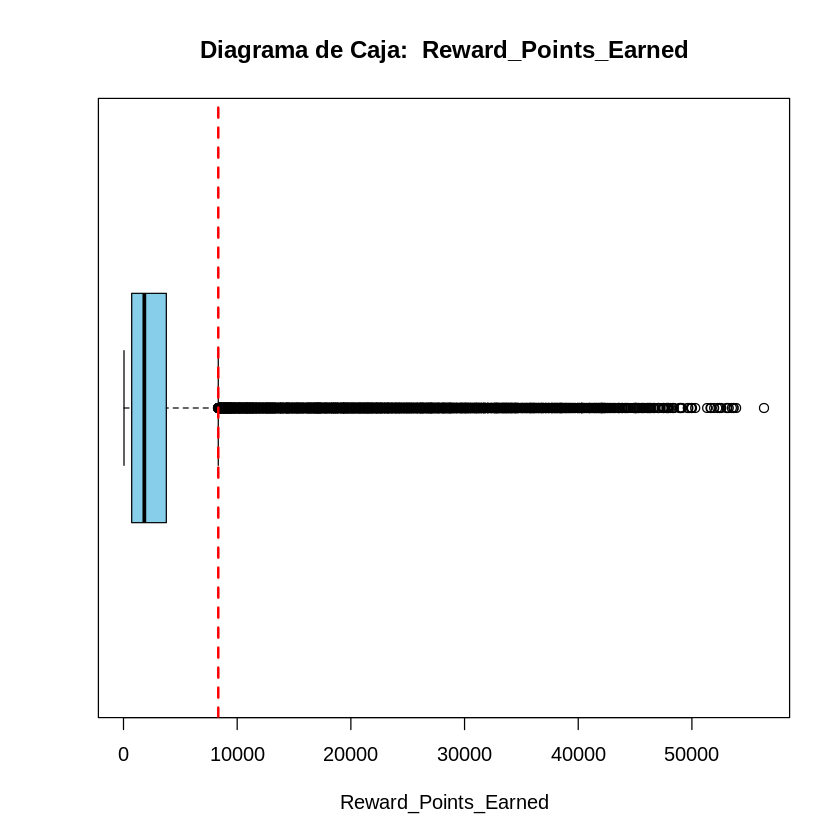



--------------------------------------------------
Análisis para la variable:  Mobile_App_Login 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
             20              44              24             -16              80 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
         0          0 


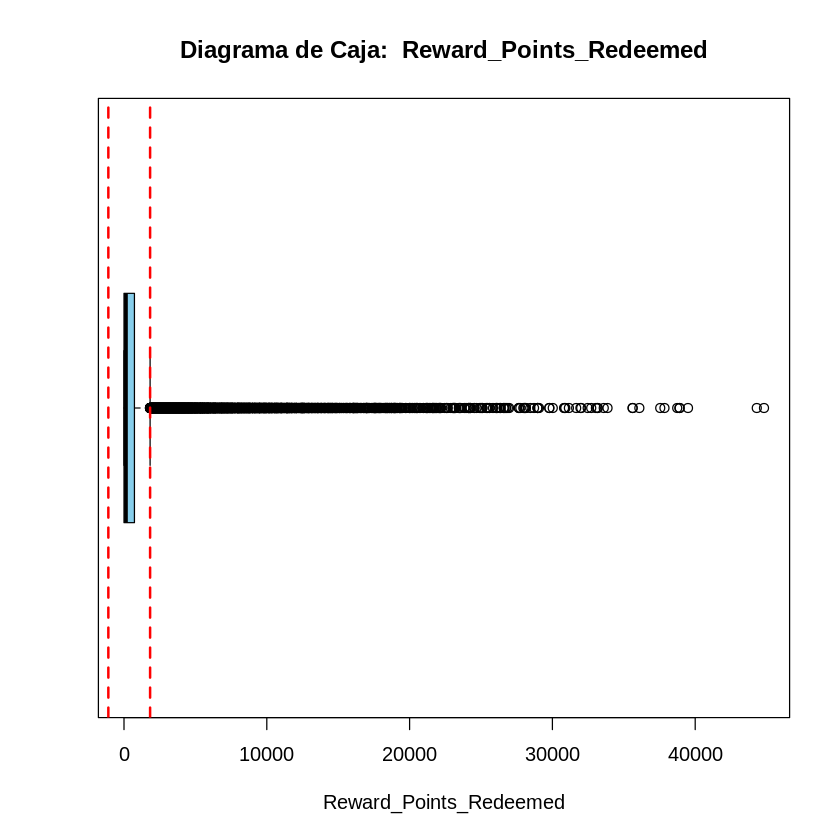



--------------------------------------------------
Análisis para la variable:  Credit_Score 
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
            585             681              96             441             825 
Conteo de atípicos univariados:
N_Atipicos Porcentaje 
   394.000      0.788 


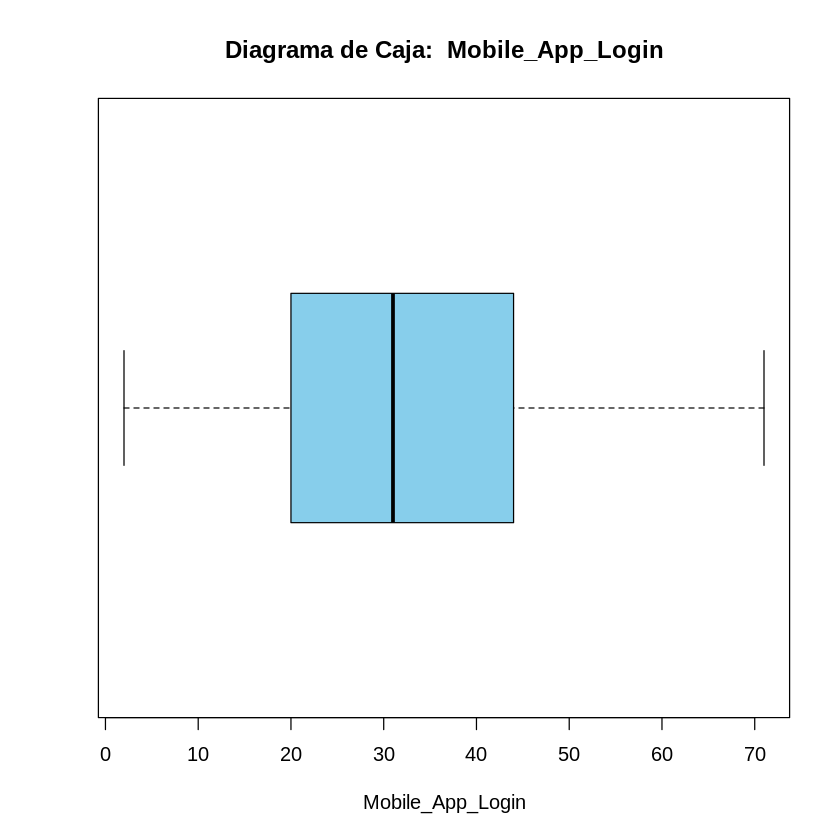

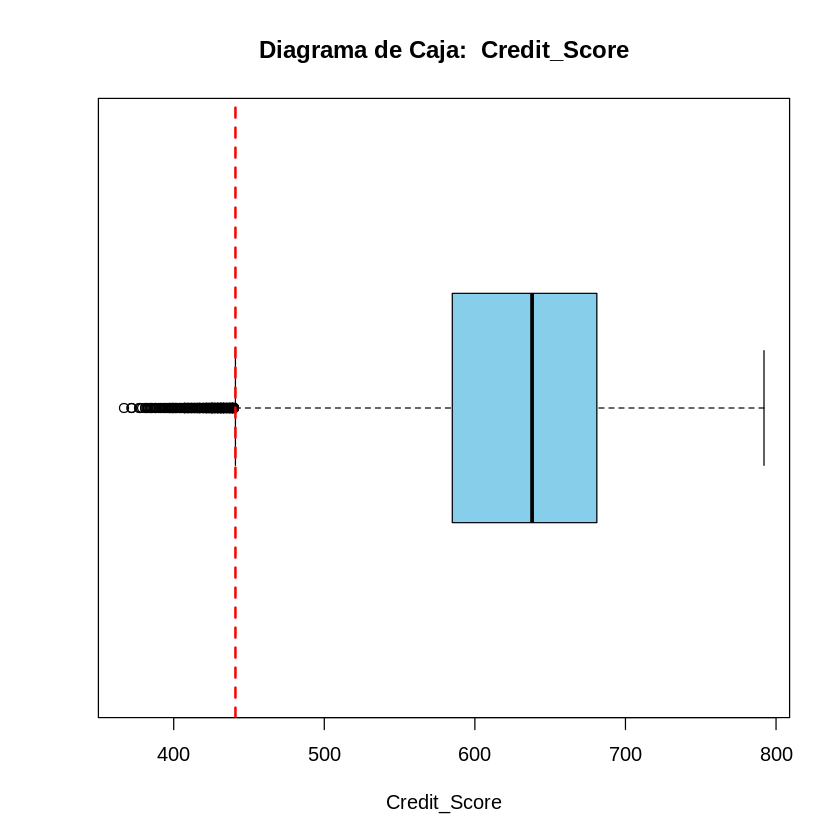

In [53]:
numeric_cols <- names(credit)[sapply(credit, is.numeric)]

for (col_name in numeric_cols) {
  current_var <- credit[[col_name]]

  # Calculate Tukey's five-number summary
  f_var <- fivenum(current_var)
  names(f_var) <- c("Mínimo", "Q1", "Mediana", "Q3", "Máximo")

  q1_var <- f_var["Q1"]
  q3_var <- f_var["Q3"]
  ric_var <- q3_var - q1_var

  lim_inf_var <- q1_var - 1.5 * ric_var
  lim_sup_var <- q3_var + 1.5 * ric_var

  cat("--------------------------------------------------\n")
  cat("Análisis para la variable: ", col_name, "\n")
  cat("--------------------------------------------------\n")

  # Print Tukey's statistics
  print(c(Q1 = q1_var, Q3 = q3_var, RIC = ric_var,
          Lim_Inferior = lim_inf_var, Lim_Superior = lim_sup_var))

  # Count univariate outliers
  atipicos_var <- current_var[current_var < lim_inf_var | current_var > lim_sup_var]
  n_atipicos_var <- length(atipicos_var)
  pct_atipicos_var <- (n_atipicos_var / length(current_var)) * 100

  cat("Conteo de atípicos univariados:\n")
  print(c(N_Atipicos = n_atipicos_var, Porcentaje = round(pct_atipicos_var, 3)))

  # Generate boxplot
  boxplot(current_var, horizontal = TRUE, col = "skyblue",
          main = paste("Diagrama de Caja: ", col_name),
          xlab = col_name)
  abline(v = c(lim_inf_var, lim_sup_var), col = "red", lty = 2, lwd = 2)

  cat("\n\n") # Add some spacing between analyses of different variables
}

**Reflexión crítica:**
Al ser una variable derivada de una simulación uniforme/normal en el conjunto sintético, el número de atípicos univariados es mínimo (`r n_atipicos_gasto` observaciones, `r sprintf("%.2f%%", pct_atipicos_gasto)`). En datos reales con asimetría positiva fuerte (como ingresos o balances), la regla de Tukey tiende a marcar colas naturales como atípicos si no se realiza una transformación previa.

---

# Módulo 5: Comparación Multivariada Estandarizada mediante Boxplots (S03)

Cuando tenemos múltiples variables cuantitativas en diferentes unidades (pesos, meses, transacciones, ratios), no es posible graficarlas juntas en su escala original.

In [19]:
cols_num <- sapply(credit, is.numeric)
credit_num <- credit[, cols_num]

## Boxplots sin estandarizar vs. estandarizados (`scale`)

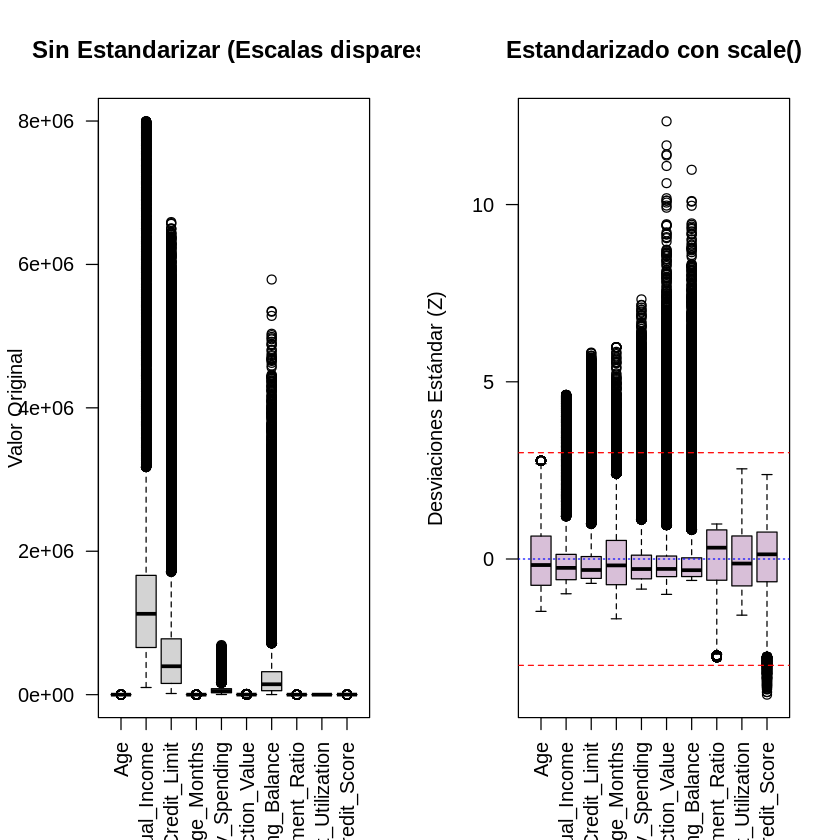

In [20]:
# Seleccionamos un subconjunto representativo de variables para visualización clara
vars_box <- c("Age", "Annual_Income", "Credit_Limit", "Card_Age_Months",
              "Monthly_Spending", "Avg_Transaction_Value", "Outstanding_Balance",
              "Payment_Ratio", "Credit_Utilization", "Credit_Score")

par(mfrow = c(1, 2))

# 1. Sin estandarizar (las variables en millones dominan y ocultan a los ratios)
boxplot(credit_num[, vars_box], las = 2, col = "lightgray",
        main = "Sin Estandarizar (Escalas dispares)",
        ylab = "Valor Original")

# 2. Estandarizado (Z-scores: media 0, varianza 1)
credit_scale <- scale(credit_num[, vars_box])
boxplot(credit_scale, las = 2, col = "thistle",
        main = "Estandarizado con scale()",
        ylab = "Desviaciones Estándar (Z)")
abline(h = 0, col = "blue", lty = 3)
abline(h = c(-3, 3), col = "red", lty = 2)

par(mfrow = c(1, 1))

## Diagnóstico de colas máximas ($Z$-score máximo)

Identificamos a cuántas desviaciones estándar de su media se encuentra el valor máximo de cada variable:

In [21]:
z_max <- apply(credit_scale, 2, max)
round(sort(z_max, decreasing = TRUE), 2)

Avg_Transaction_Value   Outstanding_Balance      Monthly_Spending 
                12.35                 10.98                  7.33 
      Card_Age_Months          Credit_Limit         Annual_Income 
                 5.97                  5.82                  4.63 
                  Age    Credit_Utilization          Credit_Score 
                 2.77                  2.54                  2.38 
        Payment_Ratio 
                 0.99

> **Lección de la Semana 3:** La estandarización `scale()` nivela el terreno de juego, permitiendo comparar simultáneamente la dispersión y la longitud relativa de las colas entre variables con órdenes de magnitud dispares ($10^6$ vs $10^{-1}$).

---

# Módulo 6: Análisis Bivariado, Correlación y el "Punto Imposible" (S01 & S03)

## Correlación bivariada y dispersión

Analizamos la relación entre el Ratio de Pago (`Payment_Ratio`) y el Puntaje Crediticio (`Credit_Score`):

In [22]:
r_pr_cs <- cor(credit$Payment_Ratio, credit$Credit_Score)
r_pr_cs

[1] 0.7671463

In [59]:
cor(credit$Annual_Income, credit$Credit_Limit)

[1] 0.9741659

Existe una fuerte correlación lineal positiva ($r = `r round(r_pr_cs, 3)`$): los clientes que pagan una proporción mayor de su deuda exhiben sistemáticamente mejores puntajes de crédito.

## Construcción y Demostración del "Punto Imposible" (S03 - Sesión 4)

Uno de los conceptos fundamentales que distingue la **Estadística Multivariante** de la univariada es que **un individuo puede ser perfectamente normal en cada variable por separado y, sin embargo, ser un valor atípico imposible en el espacio conjunto**.

### 1. Verificación de los límites univariados de Tukey

In [23]:
f_pr <- fivenum(credit$Payment_Ratio)
f_cs <- fivenum(credit$Credit_Score)

iqr_pr <- f_pr[4] - f_pr[2]
iqr_cs <- f_cs[4] - f_cs[2]

lim_pr <- c(f_pr[2] - 1.5 * iqr_pr, f_pr[4] + 1.5 * iqr_pr)
lim_cs <- c(f_cs[2] - 1.5 * iqr_cs, f_cs[4] + 1.5 * iqr_cs)

c("Límites Payment_Ratio (Inf, Sup)" = lim_pr,
  "Límites Credit_Score (Inf, Sup)" = lim_cs)

Límites Payment_Ratio (Inf, Sup)1 Límites Payment_Ratio (Inf, Sup)2 
                             0.11                              1.47 
 Límites Credit_Score (Inf, Sup)1  Límites Credit_Score (Inf, Sup)2 
                           441.00                            825.00

### 2. Creación del cliente hipotético contradictorio

Diseñamos un cliente con:
* `Payment_Ratio = 0.95` (Paga casi el $100\%$ de su saldo).
* `Credit_Score = 460` (Puntaje crediticio extremadamente bajo / de alto riesgo).

In [24]:
punto_pr <- 0.95
punto_cs <- 460

# Verificación 1: ¿Está dentro de los límites de Tukey univariados?
dentro_pr <- punto_pr >= lim_pr[1] & punto_pr <= lim_pr[2]
dentro_cs <- punto_cs >= lim_cs[1] & punto_cs <= lim_cs[2]

data.frame(
  Variable = c("Payment_Ratio", "Credit_Score"),
  Valor = c(punto_pr, punto_cs),
  Lim_Inferior = c(lim_pr[1], lim_cs[1]),
  Lim_Superior = c(lim_pr[2], lim_cs[2]),
  Es_Normal_Univariado = c(dentro_pr, dentro_cs)
)

Variable,Valor,Lim_Inferior,Lim_Superior,Es_Normal_Univariado
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
Payment_Ratio,0.95,0.11,1.47,TRUE
Credit_Score,460.00,441.00,825.00,TRUE


Ambos valores están estrictamente dentro de los bigotes univariados. Ningún filtro univariado lo marcaría como anómalo.

### 3. Visualización bivariada: Demostración del "Punto Rojo"

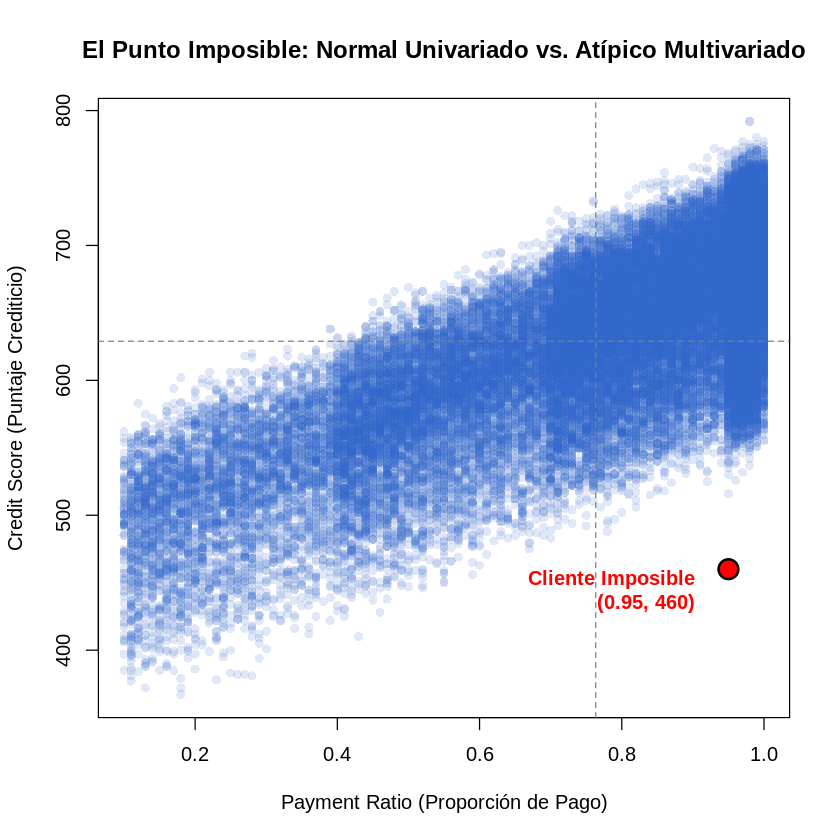

In [64]:
plot(credit$Payment_Ratio, credit$Credit_Score,
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.15),
     xlab = "Payment Ratio (Proporción de Pago)",
     ylab = "Credit Score (Puntaje Crediticio)",
     main = "El Punto Imposible: Normal Univariado vs. Atípico Multivariado")

# Dibujamos el punto en rojo
points(punto_pr, punto_cs, col = "red", pch = 19, cex = 2.2)
points(punto_pr, punto_cs, col = "black", pch = 1, cex = 2.2, lwd = 2)
text(punto_pr - 0.03, punto_cs - 20, labels = "Cliente Imposible\n(0.95, 460)", col = "red", font = 2, pos = 2)

# Cuadrantes de referencia
abline(v = mean(credit$Payment_Ratio), col = "gray50", lty = 2)
abline(h = mean(credit$Credit_Score), col = "gray50", lty = 2)

**Explicación conceptual:**
La combinación es contradictoria porque viola la covarianza del sistema: en esta población, cualquier cliente que paga el $95\%$ de su deuda (`Payment_Ratio = 0.95`) tiene un puntaje superior a $650$. Asignarle un puntaje de $460$ lo sitúa en una región del plano con densidad nula, demostrando que **la normalidad marginal no garantiza la normalidad conjunta**.

---


--------------------------------------------------
Análisis para la variable: Annual_Income
--------------------------------------------------
          Q1.Q1           Q3.Q3          RIC.Q3 Lim_Inferior.Q1 Lim_Superior.Q3 
       657770.5       1663677.0       1005906.5       -851089.2       3172536.8 


Variable,Valor,Lim_Inferior,Lim_Superior,Es_Normal_Univariado
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
Annual_Income,3e+06,-851089.2,3172537,TRUE
Credit_Limit,2e+02,-776000.0,1712000,TRUE


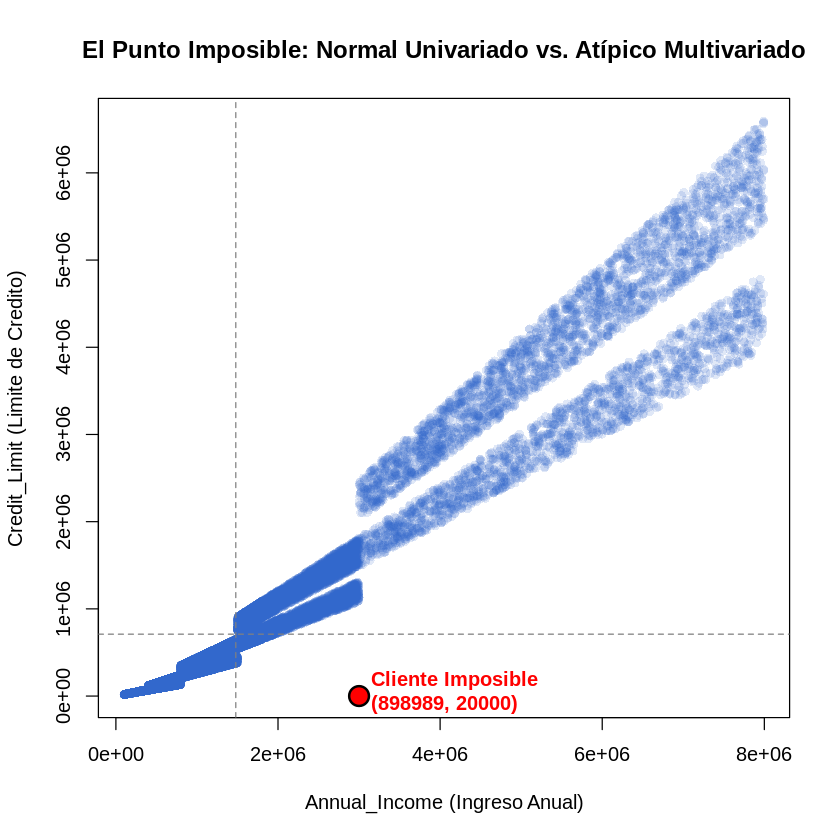

In [66]:
ingreso <- credit$Annual_Income
limite <- credit$Credit_Limit

# --- Análisis para Annual_Income ---
cat("--------------------------------------------------\n")
cat("Análisis para la variable: Annual_Income\n")
cat("--------------------------------------------------\n")

f_ingreso <- fivenum(ingreso)
names(f_ingreso) <- c("Mínimo", "Q1", "Mediana", "Q3", "Máximo")

q1_ingreso <- f_ingreso["Q1"]
q3_ingreso <- f_ingreso["Q3"]
ric_ingreso <- q3_ingreso - q1_ingreso

lim_inf_ingreso <- q1_ingreso - 1.5 * ric_ingreso
lim_sup_ingreso <- q3_ingreso + 1.5 * ric_ingreso

print(c(Q1 = q1_ingreso, Q3 = q3_ingreso, RIC = ric_ingreso,
          Lim_Inferior = lim_inf_ingreso, Lim_Superior = lim_sup_ingreso))

punto_ai <- 3000000
punto_cl <- 200

# Definir los límites de Tukey para Annual_Income y Credit_Limit
lim_ai <- c(lim_inf_ingreso, lim_sup_ingreso)

f_limite <- fivenum(limite)
names(f_limite) <- c("Mínimo", "Q1", "Mediana", "Q3", "Máximo")

q1_limite <- f_limite["Q1"]
q3_limite <- f_limite["Q3"]
ric_limite <- q3_limite - q1_limite

lim_inf_limite <- q1_limite - 1.5 * ric_limite
lim_sup_limite <- q3_limite + 1.5 * ric_limite

lim_cl <- c(lim_inf_limite, lim_sup_limite)

# Verificación 1: ¿Está dentro de los límites de Tukey univariados?
dentro_ai <- punto_ai >= lim_ai[1] & punto_ai <= lim_ai[2]
dentro_cl <- punto_cl >= lim_cl[1] & punto_cl <= lim_cl[2]

data.frame(
  Variable = c("Annual_Income", "Credit_Limit"),
  Valor = c(punto_ai, punto_cl),
  Lim_Inferior = c(lim_ai[1], lim_cl[1]),
  Lim_Superior = c(lim_ai[2], lim_cl[2]),
  Es_Normal_Univariado = c(dentro_ai, dentro_cl)
)


plot(credit$Annual_Income, credit$Credit_Limit,
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.15),
     xlab = "Annual_Income (Ingreso Anual)",
     ylab = "Credit_Limit (Limite de Credito)",
     main = "El Punto Imposible: Normal Univariado vs. Atípico Multivariado")

# Dibujamos el punto en rojo
points(punto_ai, punto_cl, col = "red", pch = 19, cex = 2.2)
points(punto_ai, punto_cl, col = "black", pch = 1, cex = 2.2, lwd = 2)
text(punto_ai, punto_cl - 20000, labels = "Cliente Imposible\n(3000000, 200)", col = "red", font = 2, pos = 4)

# Cuadrantes de referencia
abline(v = mean(credit$Annual_Income), col = "gray50", lty = 2)
abline(h = mean(credit$Credit_Limit), col = "gray50", lty = 2)

# Módulo 7: Estructura Multivariada Conjunta (S01 & S03)

## Matriz de correlaciones completa ($\mathbf{R}$)

Calculamos la matriz de correlación entre variables estratégicas de negocio:

In [26]:
vars_interes <- c("Annual_Income", "Credit_Limit", "Monthly_Spending",
                  "Outstanding_Balance", "Statement_Balance", "Payment_Amount",
                  "Payment_Ratio", "Credit_Utilization", "Reward_Points_Earned", "Credit_Score")

mat_cor <- cor(credit_num[, vars_interes], use = "complete.obs")
round(mat_cor, 3)

,Annual_Income,Credit_Limit,Monthly_Spending,Outstanding_Balance,Statement_Balance,Payment_Amount,Payment_Ratio,Credit_Utilization,Reward_Points_Earned,Credit_Score
Annual_Income,1.000,0.974,0.945,0.843,0.874,0.819,0.002,0.005,0.924,0.032
Credit_Limit,0.974,1.000,0.940,0.866,0.894,0.839,0.001,0.005,0.958,0.035
Monthly_Spending,0.945,0.940,1.000,0.814,0.855,0.805,0.003,0.005,0.980,0.033
Outstanding_Balance,0.843,0.866,0.814,1.000,0.997,0.932,-0.002,0.293,0.830,-0.145
Statement_Balance,0.874,0.894,0.855,0.997,1.000,0.936,-0.001,0.262,0.866,-0.125
Payment_Amount,0.819,0.839,0.805,0.932,0.936,1.000,0.192,0.246,0.815,0.031
Payment_Ratio,0.002,0.001,0.003,-0.002,-0.001,0.192,1.000,0.005,0.003,0.767
Credit_Utilization,0.005,0.005,0.005,0.293,0.262,0.246,0.005,1.000,0.005,-0.599
Reward_Points_Earned,0.924,0.958,0.980,0.830,0.866,0.815,0.003,0.005,1.000,0.036
Credit_Score,0.032,0.035,0.033,-0.145,-0.125,0.031,0.767,-0.599,0.036,1.000


### Síntesis de correlaciones observadas:
1. **Colinealidad casi perfecta ($r > 0.95$):**
   * `Outstanding_Balance` y `Statement_Balance` ($r = 0.997$)
   * `Monthly_Spending` y `Reward_Points_Earned` ($r = 0.980$)
   * `Credit_Limit` y `Annual_Income` ($r = 0.843$)
2. **Determinantes del riesgo:**
   * `Payment_Ratio` con `Credit_Score` ($r = 0.767$)
   * `Credit_Utilization` con `Credit_Score` ($r = -0.599$)

## Matriz de dispersión multivariada (`pairs`)

Visualizamos las relaciones bivariadas simultáneas:

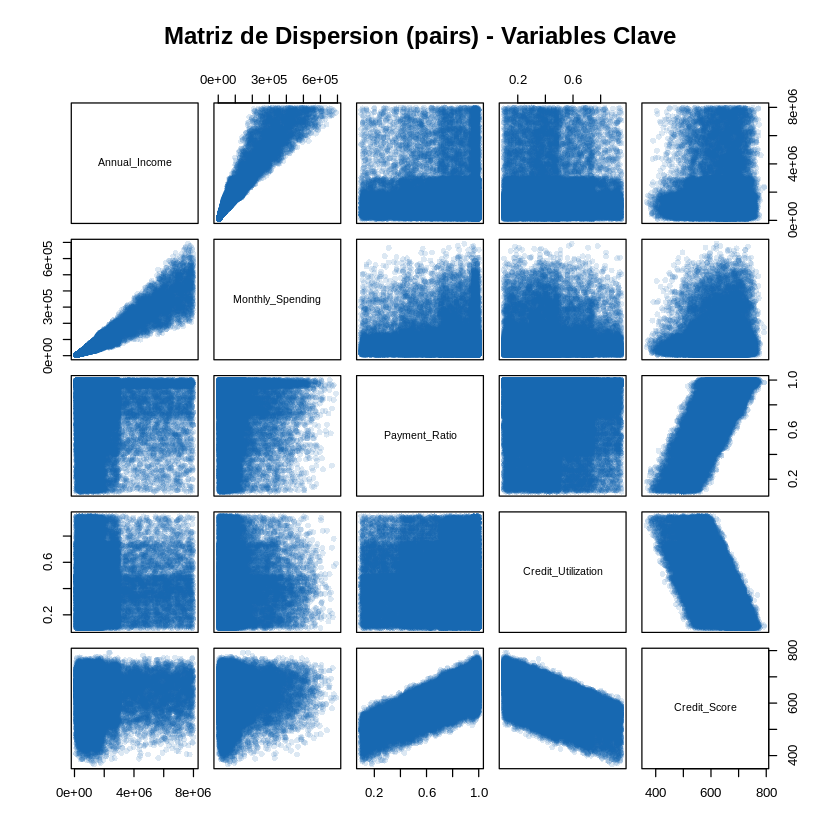

In [27]:
vars_pairs <- c("Annual_Income", "Monthly_Spending", "Payment_Ratio",
                "Credit_Utilization", "Credit_Score")

pairs(credit_num[, vars_pairs],
      pch = 16,
      col = rgb(0.1, 0.4, 0.7, 0.15),
      main = "Matriz de Dispersion (pairs) - Variables Clave")

## Reflexión teórica: La paradoja de las 55 dimensiones bivariadas

Con $p = 10$ variables numéricas existen $\binom{10}{2} = 45$ diagramas de dispersión bivariados (y con $p = 11$, $55$ diagramas).

> **Pregunta fundamental:** Si examinamos todos los diagramas de dispersión 2D y ninguno muestra un punto fuera de las nubes, **¿podemos concluir que no hay valores atípicos en el conjunto?**
>
> **Respuesta metodológica:** **No.** De la misma manera que un punto puede ser normal en cada dimensión 1D pero imposible en 2D (el punto rojo), un individuo puede proyectarse dentro de las elipses de todas las parejas 2D y aun así ser un valor atípico extremo en un subespacio de dimensión $\geq 3$ (o a lo largo de una combinación lineal de variables). Para detectar estos casos se requieren métricas de distancia multivariante (como la Distancia de Mahalanobis $D^2$) y transformaciones factoriales (como PCA).

---

# Conclusiones del Análisis Multidimensional (Semanas 1 a 3)

1. **Conclusión Univariada (S01/S03):** Las variables de puntaje y capacidad crediticia presentan distribuciones simétricas y acotadas. El uso de la regla de Sturges ($k \approx 13$) y la calibración gráfica de los histogramas demostró que una partición moderada (`breaks = 20`) revela la forma unimodal real sin el sobreajuste que producen particiones finas.
2. **Conclusión Bivariada (S01/S03):** El comportamiento de pago es el principal motor del puntaje de riesgo ($r = 0.767$), mientras que la utilización del cupo actúa como factor depresor ($r = -0.599$). La demostración del punto imposible ilustra cómo un cliente con parámetros univariados plausibles puede representar una anomalía severa al romper la covarianza natural entre el ratio de pago y el riesgo.
3. **Conclusión Multivariada (S01/S02/S03):** La matriz $\mathbf{X}$ posee una alta interdependencia lineal y dimensionalidad efectiva reducida, evidenciada por correlaciones estructurales superiores a $0.90$. La inspección visual estandarizada (`scale`) y la matriz `pairs` confirman que las variables están preparadas para técnicas de reducción de dimensionalidad (como PCA).
